# Anomaly Detection on Water Pump Audio Data

Canonical notebook for the assignment pipeline:
1. **Convolutional Autoencoder** learns a latent representation from normal pump audio.
2. **Classical anomaly detectors** operate on the ConvAE latent space.
3. **File-level evaluation** aggregates window scores and tunes thresholds by balanced accuracy.

PANNs and MFCC are kept as optional sanity baselines, not as replacements for the assignment-focused ConvAE latent pipeline.

## 1. Setup and Imports

In [1]:
import os
import csv
import json
import re
from datetime import datetime
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib_cache").resolve()))

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

# Local modules
from src.config import PreprocessConfig
from src.preprocessing import process_file_list, get_spectrogram_shape, save_processed_data, load_processed_data, add_source_ids_to_metadata
from src.dataset import create_data_splits, print_split_summary, SpectrogramDataset

# Configuration
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
DATA_RAW = Path("data/raw")
DATA_PROCESSED = Path("data/processed")
LATENTS_CACHE = DATA_PROCESSED / "latents_cache"
LATENTS_CACHE.mkdir(parents=True, exist_ok=True)

# Evaluation protocol
AGGREGATION_STRATEGY = "mean"
THRESHOLD_METRIC = "balanced_accuracy"
RUN_PANNS_BASELINE = False  # Optional and memory-heavy; set True to run cached/extracted PANNs baseline.

# Run artifacts: figures, tables, and metric snapshots are saved under a timestamped folder.
SAVE_OUTPUTS = True
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_ROOT = Path("outputs") / "notebook_runs"
OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
METRICS_DIR = OUTPUT_DIR / "metrics"

if SAVE_OUTPUTS:
    for output_subdir in [FIGURES_DIR, TABLES_DIR, METRICS_DIR]:
        output_subdir.mkdir(parents=True, exist_ok=True)
    print(f"Saving notebook artifacts to: {OUTPUT_DIR}")


def slugify_name(name):
    """Create a stable filesystem-friendly artifact name."""
    slug = re.sub(r"[^A-Za-z0-9]+", "_", str(name)).strip("_").lower()
    return slug or "artifact"


def json_safe(value):
    """Convert common NumPy/PyTorch/path values to JSON-serializable objects."""
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if torch.is_tensor(value):
        return value.detach().cpu().tolist()
    return value


def save_figure(fig, name, dpi=160):
    """Save a Matplotlib figure and return the output path."""
    if not SAVE_OUTPUTS:
        return None
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{slugify_name(name)}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


def save_text_artifact(text, name, subdir="tables", suffix=".txt"):
    """Save plain-text tables or summaries and return the output path."""
    if not SAVE_OUTPUTS:
        return None
    base_dir = OUTPUT_DIR / subdir
    base_dir.mkdir(parents=True, exist_ok=True)
    path = base_dir / f"{slugify_name(name)}{suffix}"
    path.write_text(str(text), encoding="utf-8")
    print(f"Saved artifact: {path}")
    return path


def save_json_artifact(obj, name, subdir="metrics"):
    """Save dictionaries/lists as JSON and return the output path."""
    if not SAVE_OUTPUTS:
        return None
    base_dir = OUTPUT_DIR / subdir
    base_dir.mkdir(parents=True, exist_ok=True)
    path = base_dir / f"{slugify_name(name)}.json"
    path.write_text(json.dumps(json_safe(obj), indent=2), encoding="utf-8")
    print(f"Saved artifact: {path}")
    return path


def save_results_csv(results_dict, name):
    """Save scalar metrics from a results dictionary as CSV."""
    if not SAVE_OUTPUTS:
        return None
    metric_fields = [
        "threshold", "accuracy", "balanced_accuracy", "precision", "recall",
        "f1", "auc_roc", "auc_pr", "threshold_metric", "aggregation",
    ]
    tune_fields = ["accuracy", "balanced_accuracy", "precision", "recall", "f1"]
    fieldnames = ["method", *metric_fields, *[f"tune_{field}" for field in tune_fields]]
    rows = []
    for method, results in results_dict.items():
        row = {"method": method}
        for field in metric_fields:
            row[field] = json_safe(results.get(field))
        tune_metrics = results.get("tune_metrics") or {}
        for field in tune_fields:
            row[f"tune_{field}"] = json_safe(tune_metrics.get(field))
        rows.append(row)

    TABLES_DIR.mkdir(parents=True, exist_ok=True)
    path = TABLES_DIR / f"{slugify_name(name)}.csv"
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved artifact: {path}")
    return path


def save_comparison_table(results_dict, name):
    """Save the printable comparison table plus CSV and raw JSON metrics."""
    table = create_comparison_table(results_dict)
    save_text_artifact(table, name, subdir="tables", suffix=".txt")
    save_results_csv(results_dict, name)
    save_json_artifact(results_dict, name, subdir="metrics")
    return table

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


Saving notebook artifacts to: outputs/notebook_runs/20260620_212421
Using device: mps


## 2. Data Splitting

Split strategy:
- **train-normal**: 80% AE training, 20% AE validation
- **test-normal**: 50% IF threshold tuning, 50% final test  
- **anomaly**: 30% IF threshold tuning, 70% final test

The Isolation Forest will be fitted on **all train-normal** latent representations (both AE train and val sets).

In [2]:
# Create data splits at file level
splits = create_data_splits(
    train_normal_dir=DATA_RAW / "train-normal",
    test_normal_dir=DATA_RAW / "test-normal",
    anomaly_dir=DATA_RAW / "anomaly",
    ae_train_ratio=0.8,
    if_threshold_normal_ratio=0.5,
    if_threshold_anomaly_ratio=0.3,
    seed=SEED
)

print_split_summary(splits)

DATA SPLIT SUMMARY

[Autoencoder]
  Training:    1792 files
  Validation:   449 files

[Isolation Forest Training]
  Normal:      2241 files (latent representations)

[Isolation Forest Validation (and Tuning)]
  Normal:       200 files
  Anomaly:      136 files

[Final Test]
  Normal:       200 files
  Anomaly:      320 files


### 2.1 dB Distribution Analysis

Before preprocessing, analyze the distribution of dB values in the raw audio to choose an appropriate noise floor (`db_min`). This helps determine where "signal" ends and "noise" begins.

Analyzing dB distribution with fixed reference (use_fixed_ref=True)...


Computing dB percentiles: 100%|██████████| 100/100 [00:40<00:00,  2.49it/s]



Percentile Analysis:
  Min: -58.9 dB
   1th percentile: -46.1 dB
   5th percentile: -41.6 dB
  10th percentile: -39.1 dB
  25th percentile: -35.1 dB
  50th percentile: -29.9 dB
  75th percentile: -24.1 dB
  90th percentile: -18.5 dB
  95th percentile: -15.2 dB
  99th percentile: -10.0 dB
  Max: 3.9 dB

>>> Recommended db_min: -46.1 dB (1st percentile)
>>> Recommended db_max: -10.0 dB (99th percentile)


Saved figure: outputs/notebook_runs/20260620_212421/figures/db_distribution_fixed_reference.png


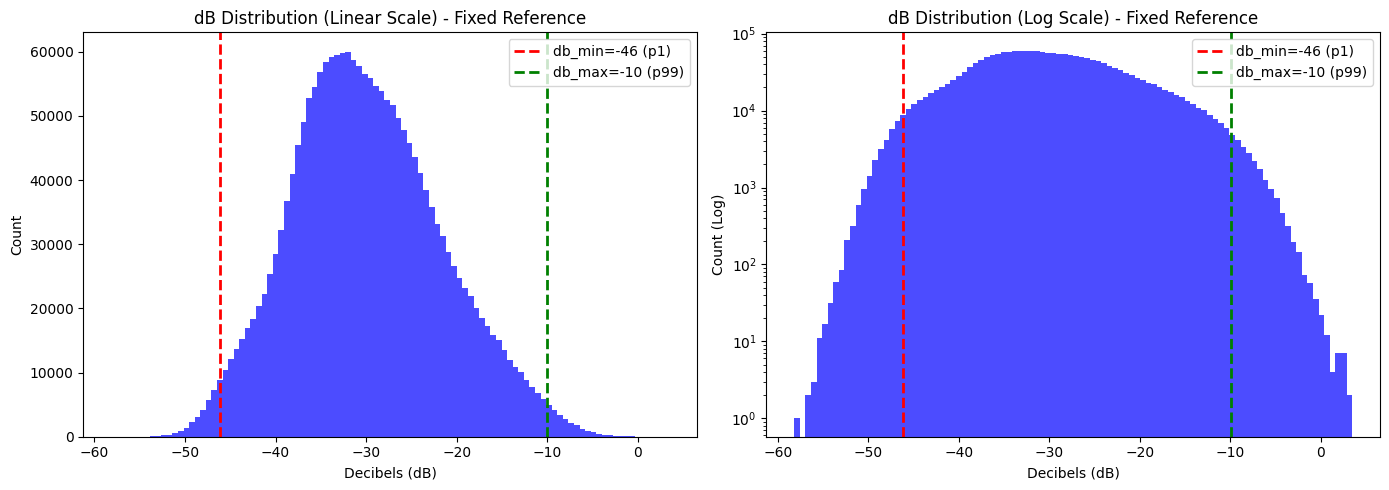


To use percentile-based normalization, set:
  preprocess_config = PreprocessConfig(
      use_fixed_ref=True,
      global_norm=True,
      db_min=-46.1,
      db_max=-10.0
  )
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/db_percentile_analysis.json


PosixPath('outputs/notebook_runs/20260620_212421/metrics/db_percentile_analysis.json')

In [3]:
# Analyze dB distribution to choose db_min/db_max thresholds
# Using use_fixed_ref=True to preserve absolute intensity information
from src.preprocessing import compute_db_percentiles

# Create a temporary config with use_fixed_ref=True to see actual dB distribution
temp_config = PreprocessConfig(use_fixed_ref=True)

# Compute percentiles from training data
print("Analyzing dB distribution with fixed reference (use_fixed_ref=True)...")
percentile_stats = compute_db_percentiles(
    files=splits['ae_train'],
    config=temp_config,
    n_samples=100,
    percentiles=[1, 5, 10, 25, 50, 75, 90, 95, 99],
    seed=SEED
)

# Print results
print("\nPercentile Analysis:")
print(f"  Min: {percentile_stats['min']:.1f} dB")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    key = f'p{p}'
    if key in percentile_stats:
        print(f"  {p:2d}th percentile: {percentile_stats[key]:.1f} dB")
print(f"  Max: {percentile_stats['max']:.1f} dB")

print(f"\n>>> Recommended db_min: {percentile_stats['recommended_db_min']:.1f} dB (1st percentile)")
print(f">>> Recommended db_max: {percentile_stats['recommended_db_max']:.1f} dB (99th percentile)")

# Visualize the distribution
import librosa
from tqdm import tqdm

# Collect dB values for histogram
n_samples = 50
sample_files = np.random.choice(splits['ae_train'], size=min(n_samples, len(splits['ae_train'])), replace=False)
all_db_values = []

for file_path in tqdm(sample_files, desc="Collecting dB values for histogram"):
    y, _ = librosa.load(file_path, sr=16000, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=16000, n_fft=1024, hop_length=512, n_mels=128)
    S_db = librosa.power_to_db(S, ref=1.0)  # Fixed reference
    all_db_values.extend(S_db.flatten())

all_db_values = np.array(all_db_values)

# Plot histogram with recommended thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

db_min_rec = percentile_stats['recommended_db_min']
db_max_rec = percentile_stats['recommended_db_max']

for ax, log_scale in zip(axes, [False, True]):
    ax.hist(all_db_values, bins=100, alpha=0.7, color='blue', log=log_scale)
    ax.axvline(x=db_min_rec, color='r', linestyle='--', linewidth=2, label=f'db_min={db_min_rec:.0f} (p1)')
    ax.axvline(x=db_max_rec, color='g', linestyle='--', linewidth=2, label=f'db_max={db_max_rec:.0f} (p99)')
    ax.set_xlabel("Decibels (dB)")
    ax.set_ylabel("Count" + (" (Log)" if log_scale else ""))
    ax.set_title(f"dB Distribution ({'Log' if log_scale else 'Linear'} Scale) - Fixed Reference")
    ax.legend()

plt.tight_layout()
save_figure(fig, "db_distribution_fixed_reference")
plt.show()

print(f"\nTo use percentile-based normalization, set:")
print(f"  preprocess_config = PreprocessConfig(")
print(f"      use_fixed_ref=True,")
print(f"      global_norm=True,")
print(f"      db_min={db_min_rec:.1f},")
print(f"      db_max={db_max_rec:.1f}")
print(f"  )")
save_json_artifact(percentile_stats, "db_percentile_analysis")

## 3. Preprocessing

Convert audio files to log-Mel spectrograms:
- Sample rate: 16 kHz
- Window: 2 seconds with 50% overlap → 9 windows per 10s file
- Mel bands: 128
- Output shape: (128, 64) per spectrogram (63 natural frames, zero-padded to 64)

**Caching**: Processed spectrograms are saved to `data/processed/` on first run, then loaded from cache on subsequent runs.

In [4]:
# Preprocessing configuration
# use_fixed_ref=True preserves absolute intensity (ref=1.0 instead of per-spectrogram max)
# global_norm=True uses the percentile-based dB range from Section 2.1 analysis
preprocess_config = PreprocessConfig(
    use_fixed_ref=True,
    global_norm=True,
    db_min=-46.1,   # 1st percentile from training data dB analysis
    db_max=-10.0    # 99th percentile from training data dB analysis
)

print(f"Sample rate: {preprocess_config.sr} Hz")
print(f"Window: {preprocess_config.window_sec}s, Hop: {preprocess_config.hop_sec}s")
print(f"Spectrogram shape: {get_spectrogram_shape(preprocess_config)}")
print(f"Normalization: global fixed-ref (dB range [{preprocess_config.db_min}, {preprocess_config.db_max}])")

Sample rate: 16000 Hz
Window: 2.0s, Hop: 1.0s
Spectrogram shape: (128, 64)
Normalization: global fixed-ref (dB range [-46.1, -10.0])


In [5]:
def metadata_has_source_id(metadata):
    return metadata and all("source_id" in item for item in metadata)


def save_metadata(metadata, cache_dir, name):
    with open(Path(cache_dir) / f"{name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)


def load_or_process(name, files, config, cache_dir):
    """Load from cache if valid, migrate old metadata if possible, otherwise process and save."""
    cache_dir = Path(cache_dir)
    cache_file = cache_dir / f"{name}_spectrograms.npy"
    metadata_file = cache_dir / f"{name}_metadata.json"

    if cache_file.exists() and metadata_file.exists():
        specs, meta = load_processed_data(cache_dir, name)
        if metadata_has_source_id(meta):
            print(f"Loading {name} from cache...")
            return specs, meta

        try:
            meta = add_source_ids_to_metadata(meta, files)
            save_metadata(meta, cache_dir, name)
            print(f"Migrated {name} cached metadata with source_id; spectrogram cache reused.")
            return specs, meta
        except KeyError as exc:
            print(f"Could not migrate {name} metadata ({exc}); reprocessing.")

    else:
        print(f"Processing {name}...")

    specs, meta = process_file_list(files, config, desc=name)
    save_processed_data(specs, meta, cache_dir, name)
    return specs, meta


def groups_from_metadata(metadata):
    """Return one source-file group id per window."""
    return np.array([item.get("source_id") or item["source_file"] for item in metadata])


def attach_protocol(results, name, threshold_metric, aggregation, tune_metrics):
    results["name"] = name
    results["threshold_metric"] = threshold_metric
    results["aggregation"] = aggregation
    results["tune_metrics"] = tune_metrics
    return results

In [6]:
# Process AE training and validation data (with caching)
ae_train_specs, ae_train_meta = load_or_process("ae_train", splits['ae_train'], preprocess_config, DATA_PROCESSED)
ae_val_specs, ae_val_meta = load_or_process("ae_val", splits['ae_val'], preprocess_config, DATA_PROCESSED)

print(f"\nAE Train: {ae_train_specs.shape}")
print(f"AE Val:   {ae_val_specs.shape}")

Migrated ae_train cached metadata with source_id; spectrogram cache reused.
Migrated ae_val cached metadata with source_id; spectrogram cache reused.

AE Train: (16128, 128, 64)
AE Val:   (4041, 128, 64)


## 4. Visualization

Sanity check: visualize sample spectrograms to verify preprocessing is working correctly.

Saved figure: outputs/notebook_runs/20260620_212421/figures/sample_log_mel_spectrograms.png


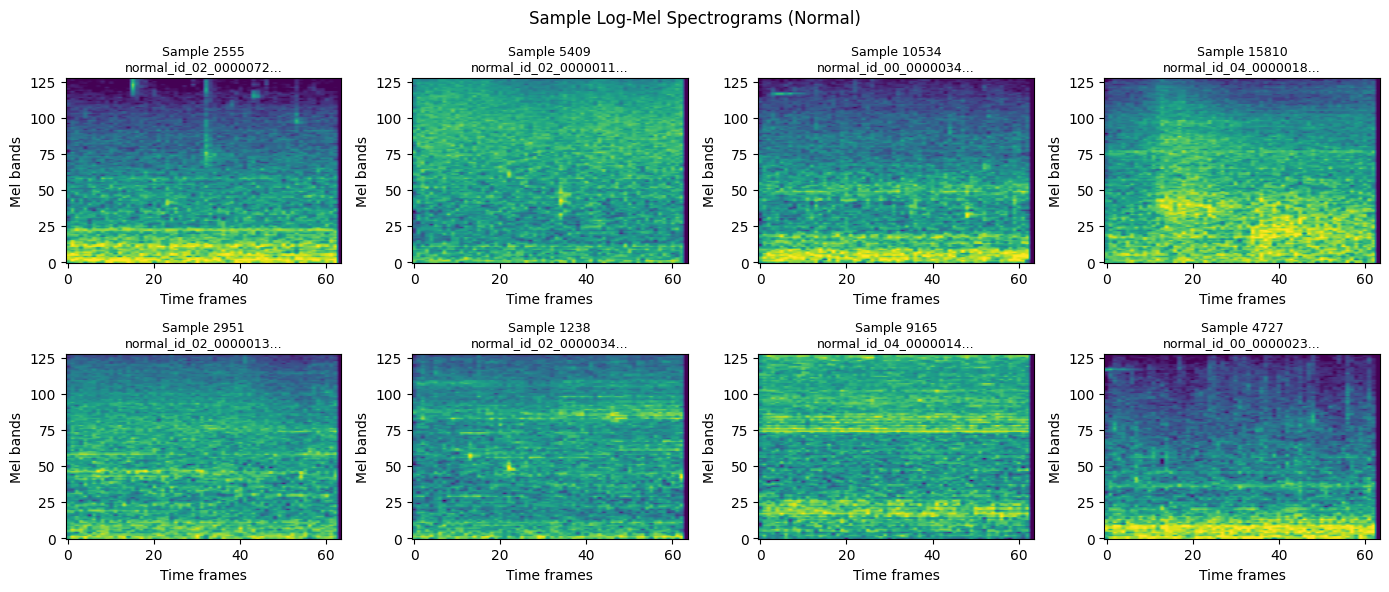

Value range: [0.000, 1.000]
Mean: 0.453, Std: 0.224
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/spectrogram_value_summary.json


PosixPath('outputs/notebook_runs/20260620_212421/metrics/spectrogram_value_summary.json')

In [7]:
# Visualize sample spectrograms from training data
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(ae_train_specs))
    spec = ae_train_specs[idx]
    
    im = ax.imshow(spec, aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(f"Sample {idx}\n{ae_train_meta[idx]['source_file'][:20]}...", fontsize=9)
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bands")

plt.suptitle("Sample Log-Mel Spectrograms (Normal)", fontsize=12)
plt.tight_layout()
save_figure(fig, "sample_log_mel_spectrograms")
plt.show()

# Value distribution
print(f"Value range: [{ae_train_specs.min():.3f}, {ae_train_specs.max():.3f}]")
print(f"Mean: {ae_train_specs.mean():.3f}, Std: {ae_train_specs.std():.3f}")
save_json_artifact({
    "min": ae_train_specs.min(),
    "max": ae_train_specs.max(),
    "mean": ae_train_specs.mean(),
    "std": ae_train_specs.std(),
}, "spectrogram_value_summary")

## 5. PyTorch DataLoaders

Wrap spectrograms in PyTorch Datasets and create DataLoaders for training.

In [8]:
# Hyperparameters
BATCH_SIZE = 64

# Create datasets
train_dataset = SpectrogramDataset(ae_train_specs)
val_dataset = SpectrogramDataset(ae_val_specs)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# Verify batch shape
batch = next(iter(train_loader))
print(f"\nBatch spectrogram shape: {batch['spectrogram'].shape}")  # Expected: (64, 1, 128, 64)

Train batches: 252
Val batches:   64

Batch spectrogram shape: torch.Size([64, 1, 128, 64])


## 6. Convolutional Autoencoder

The ConvAE learns to compress normal pump spectrograms into a latent representation and reconstruct them. The key insight for anomaly detection is that:
- Normal samples: Should reconstruct well (low error)
- Anomalous samples: Should reconstruct poorly (high error)

### Architecture Overview
```
Input: (batch, 1, 128, 64)
       ↓
Encoder: 4 Conv layers (stride=2) → Flatten → Linear
       ↓
Latent: (batch, latent_dim)
       ↓
Decoder: Linear → Reshape → 4 ConvTranspose layers (stride=2)
       ↓
Output: (batch, 1, 128, 64)
```

In [9]:
import time
from src.models import ConvAE, ConvAEConfig, train_epoch, validate, save_checkpoint, load_checkpoint, plot_training_history

# Model configuration
ae_config = ConvAEConfig(
    # Architecture
    input_channels=1,
    input_height=128,
    input_width=64,
    latent_dim=64,         # Bottleneck: 16384 → 64 (256x) — forces specialization on normal patterns
    base_channels=32,      # Channel progression: 32 → 64 → 128 → 256
    num_layers=4,
    dropout_rate=0.0,      # Disabled: AE should fit normal data precisely

    # Training
    learning_rate=1e-3,
    weight_decay=1e-5,
    epochs=100,
    patience=15,
    min_delta=1e-4,

    # LR Scheduler
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=5,
)

print("ConvAE Configuration:")
print(f"  Latent dimension: {ae_config.latent_dim}")
print(f"  Encoder channels: {ae_config.encoder_channels}")
print(f"  Bottleneck shape: {ae_config.bottleneck_shape}")
print(f"  Bottleneck size:  {ae_config.bottleneck_size}")
print(f"  Compression ratio: {128*64 / ae_config.latent_dim:.1f}x")
print(f"  Dropout rate: {ae_config.dropout_rate}")

ConvAE Configuration:
  Latent dimension: 64
  Encoder channels: [32, 64, 128, 256]
  Bottleneck shape: (256, 16, 4)
  Bottleneck size:  16384
  Compression ratio: 128.0x
  Dropout rate: 0.0


In [10]:
# Instantiate or load model
checkpoint_path = Path("checkpoints") / "conv_ae_best.pt"
FORCE_RETRAIN_AE = False

if checkpoint_path.exists() and not FORCE_RETRAIN_AE:
    model, ae_config, history = load_checkpoint(checkpoint_path, device)
    model_loaded_from_checkpoint = True
    optimizer = None
    scheduler = None
    print(f"Loaded existing ConvAE checkpoint: {checkpoint_path}")
else:
    model = ConvAE(ae_config).to(device)
    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    model_loaded_from_checkpoint = False
    print("Initialized new ConvAE model. Set FORCE_RETRAIN_AE=False to reuse an existing checkpoint.")

# Model summary
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model on device: {device}")
print(f"Total parameters: {count_parameters(model):,}")
print(f"  Encoder: {count_parameters(model.encoder):,}")
print(f"  Decoder: {count_parameters(model.decoder):,}")

Loaded existing ConvAE checkpoint: checkpoints/conv_ae_best.pt
Model on device: mps
Total parameters: 2,890,433
  Encoder: 1,437,440
  Decoder: 1,452,993


### 6.1 Training

Train the autoencoder on normal samples only. Early stopping to help preventing overfitting.

In [11]:
# Train only when no checkpoint was loaded, or when FORCE_RETRAIN_AE=True.
if model_loaded_from_checkpoint:
    print("Skipping ConvAE training because an existing checkpoint was loaded.")
else:
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=ae_config.learning_rate,
        weight_decay=ae_config.weight_decay,
    )

    scheduler = None
    if ae_config.use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=ae_config.scheduler_factor,
            patience=ae_config.scheduler_patience,
        )

    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    print(f"Training for up to {ae_config.epochs} epochs")
    print(f"Early stopping patience: {ae_config.patience}")
    print("-" * 60)

    for epoch in range(ae_config.epochs):
        start_time = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        epoch_time = time.time() - start_time

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        if val_loss < best_val_loss - ae_config.min_delta:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"Epoch {epoch+1:3d}/{ae_config.epochs} | "
              f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
              f"LR: {current_lr:.2e} | Time: {epoch_time:.1f}s")

        if scheduler is not None:
            scheduler.step(val_loss)

        if patience_counter >= ae_config.patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nRestored best model with val_loss: {best_val_loss:.6f}")

Skipping ConvAE training because an existing checkpoint was loaded.


Saved figure: outputs/notebook_runs/20260620_212421/figures/convae_training_history.png
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/convae_training_history.json


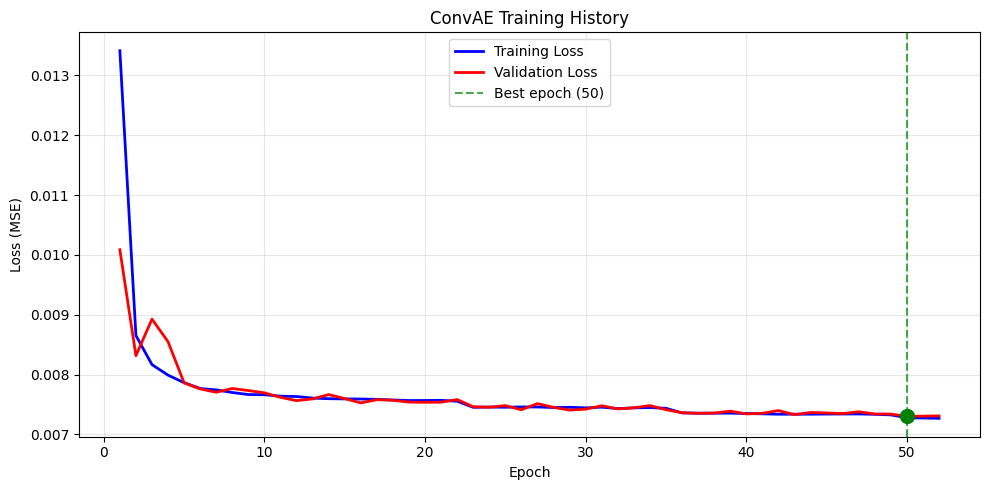


Training summary:
  Total epochs: 52
  Best validation loss: 0.007303
  Final training loss: 0.007270


In [12]:
# Plot training history
if history.get('train_loss') and history.get('val_loss'):
    fig, ax = plot_training_history(history)
    save_figure(fig, "convae_training_history")
    save_json_artifact(history, "convae_training_history")
    plt.show()

    print(f"\nTraining summary:")
    print(f"  Total epochs: {len(history['train_loss'])}")
    print(f"  Best validation loss: {min(history['val_loss']):.6f}")
    print(f"  Final training loss: {history['train_loss'][-1]:.6f}")
else:
    print("No training history available. Train the AE or load a checkpoint that includes history.")

### 6.2 Reconstruction Quality

Visualize how well the autoencoder reconstructs normal samples.

Saved figure: outputs/notebook_runs/20260620_212421/figures/convae_reconstruction_examples.png


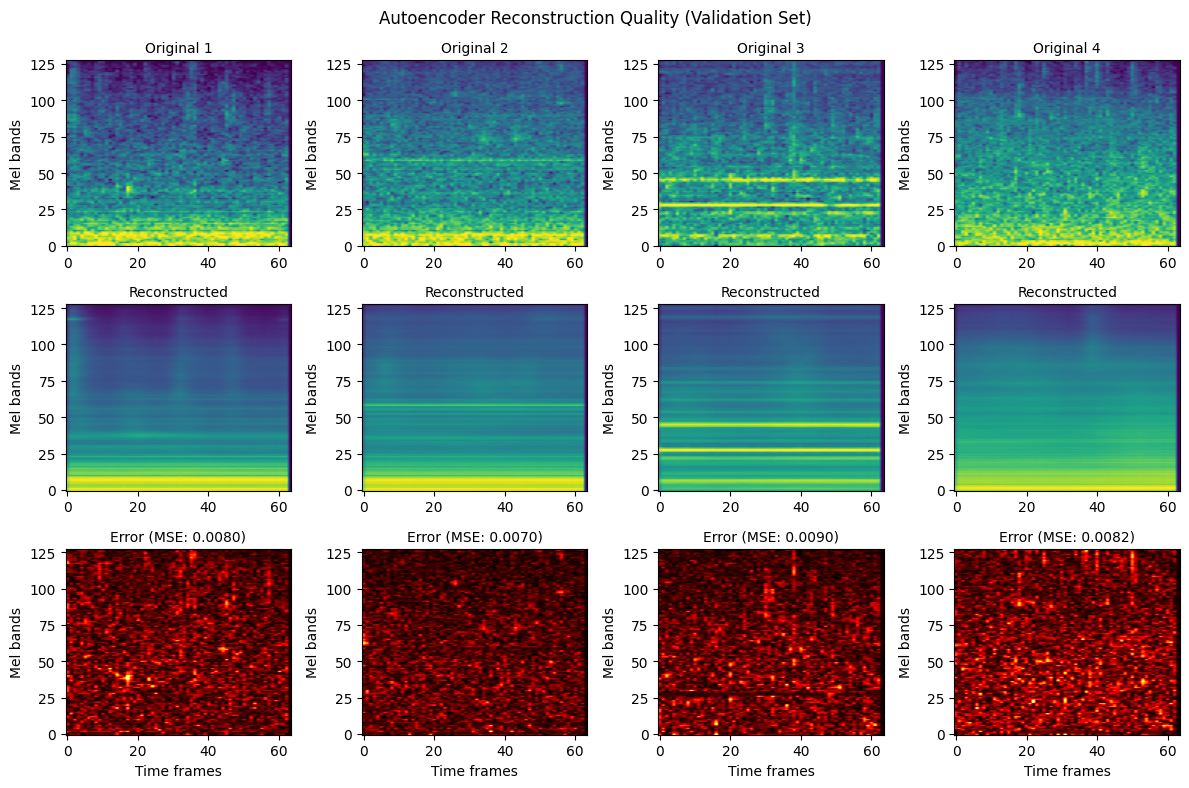

Reconstruction errors: [0.00796556 0.00703541 0.00901533 0.00823678]
Mean error: 0.008063
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/convae_reconstruction_examples.json


PosixPath('outputs/notebook_runs/20260620_212421/metrics/convae_reconstruction_examples.json')

In [13]:
# Visualize reconstructions
model.eval()
n_samples = 4

# Get random samples from validation set
indices = np.random.choice(len(ae_val_specs), n_samples, replace=False)
#indices = [100, 2700, 4500, 7000]
samples = torch.from_numpy(ae_val_specs[indices]).unsqueeze(1).float().to(device)

with torch.no_grad():
    reconstructions = model(samples)
    errors = model.reconstruction_error(samples)

# Plot original vs reconstruction
fig, axes = plt.subplots(3, n_samples, figsize=(3*n_samples, 8))

for i in range(n_samples):
    orig = samples[i, 0].cpu().numpy()
    recon = reconstructions[i, 0].cpu().numpy()
    diff = np.abs(orig - recon)
    
    # Original
    axes[0, i].imshow(orig, aspect='auto', origin='lower', cmap='viridis')
    axes[0, i].set_title(f"Original {i+1}", fontsize=10)
    axes[0, i].set_ylabel("Mel bands")
    
    # Reconstruction
    axes[1, i].imshow(recon, aspect='auto', origin='lower', cmap='viridis')
    axes[1, i].set_title(f"Reconstructed", fontsize=10)
    axes[1, i].set_ylabel("Mel bands")
    
    # Difference
    im = axes[2, i].imshow(diff, aspect='auto', origin='lower', cmap='hot')
    axes[2, i].set_title(f"Error (MSE: {errors[i]:.4f})", fontsize=10)
    axes[2, i].set_xlabel("Time frames")
    axes[2, i].set_ylabel("Mel bands")

plt.suptitle("Autoencoder Reconstruction Quality (Validation Set)", fontsize=12)
plt.tight_layout()
save_figure(fig, "convae_reconstruction_examples")
plt.show()

print(f"Reconstruction errors: {errors.cpu().numpy()}")
print(f"Mean error: {errors.mean():.6f}")
save_json_artifact({
    "sample_indices": indices,
    "reconstruction_errors": errors.cpu().numpy(),
    "mean_error": errors.mean(),
}, "convae_reconstruction_examples")

### 6.3 Save Model

Save the trained model only when this run actually trained or retrained the ConvAE.

In [14]:
# Save model checkpoint only after a training run
if model_loaded_from_checkpoint:
    print(f"Checkpoint already loaded from: {checkpoint_path}")
else:
    save_checkpoint(model, optimizer, ae_config, history, checkpoint_path, scheduler)
    print(f"Model saved to: {checkpoint_path}")

Checkpoint already loaded from: checkpoints/conv_ae_best.pt


## 7. PANNs Pre-trained Embeddings (Upper Bound Baseline)

To assess how close the lightweight ConvAE is to a performance ceiling, it is compared against **PANNs CNN14** — a large convolutional model pre-trained on **AudioSet** (millions of YouTube clips, 527 sound classes). Unlike the ConvAE, which learns features from ~2200 training files, PANNs already encodes rich, general-purpose audio semantics.

**Pipeline**: Raw audio (32 kHz) → PANNs CNN14 (frozen) → 2048-dim embedding per window → LOF / IF

If PANNs — with its vastly richer feature space — achieves only comparable performance to the ConvAE, it confirms that the model is already near the upper bound of what is achievable on this dataset.

In [15]:
import librosa
from tqdm import tqdm

# PANNs is optional. Imports and extraction are lazy so the default notebook path
# stays focused on the ConvAE assignment pipeline.
PANNS_SR = 32000
PANNS_CHECKPOINT_PATH = os.environ.get("PANNS_CHECKPOINT_PATH")
PANNS_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PANNS_IMPORT_ERROR = None
AudioTagging = None


def get_audio_tagging_class():
    global AudioTagging, PANNS_IMPORT_ERROR
    if AudioTagging is not None:
        return AudioTagging
    try:
        from panns_inference import AudioTagging as ImportedAudioTagging
        AudioTagging = ImportedAudioTagging
        return AudioTagging
    except Exception as exc:
        PANNS_IMPORT_ERROR = exc
        return None


def panns_cache_paths(cache_dir, name):
    cache_dir = Path(cache_dir)
    new_data = cache_dir / f"{name}_embeddings.npy"
    old_data = cache_dir / f"{name}_spectrograms.npy"
    metadata = cache_dir / f"{name}_metadata.json"
    return new_data, old_data, metadata


def load_panns_cache(cache_dir, name):
    new_data, old_data, metadata = panns_cache_paths(cache_dir, name)
    data_path = new_data if new_data.exists() else old_data
    if data_path.exists() and metadata.exists():
        return np.load(data_path), json.load(open(metadata))
    return None, None


def save_panns_cache(embeddings, metadata, cache_dir, name):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    np.save(cache_dir / f"{name}_embeddings.npy", embeddings)
    with open(cache_dir / f"{name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)


def extract_panns_embeddings(files, window_sec=2.0, hop_sec=1.0, sr=PANNS_SR, device=PANNS_DEVICE, desc=""):
    """Extract PANNs CNN14 embeddings from audio files using windowed approach."""
    audio_tagging_cls = get_audio_tagging_class()
    if audio_tagging_cls is None:
        raise RuntimeError(f"panns-inference is unavailable: {PANNS_IMPORT_ERROR}")
    if not PANNS_CHECKPOINT_PATH:
        raise RuntimeError("Set PANNS_CHECKPOINT_PATH to extract new PANNs embeddings.")

    at = audio_tagging_cls(checkpoint_path=PANNS_CHECKPOINT_PATH, device=device)
    all_embeddings = []
    all_meta = []
    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)

    for file_path in tqdm(files, desc=desc):
        file_path = Path(file_path)
        waveform, _ = librosa.load(file_path, sr=sr, mono=True)
        source_dir = file_path.parent.name

        start = 0
        win_idx = 0
        while start + window_samples <= len(waveform):
            window = waveform[start:start + window_samples]
            _, embedding = at.inference(window[None, :])
            all_embeddings.append(embedding[0])
            all_meta.append({
                "source_file": file_path.name,
                "source_dir": source_dir,
                "source_id": f"{source_dir}/{file_path.name}",
                "window_idx": win_idx,
                "start_sec": win_idx * hop_sec,
                "end_sec": win_idx * hop_sec + window_sec,
            })
            start += hop_samples
            win_idx += 1

    if not all_embeddings:
        raise ValueError("No PANNs embeddings were produced.")
    return np.stack(all_embeddings), all_meta


def load_or_extract_panns(name, files, cache_dir, **kwargs):
    """Load PANNs embeddings from cache or optionally extract them."""
    embs, meta = load_panns_cache(cache_dir, name)
    if embs is not None:
        print(f"Loading {name} PANNs embeddings from cache...")
        return embs, meta

    audio_tagging_cls = get_audio_tagging_class()
    if audio_tagging_cls is None or not PANNS_CHECKPOINT_PATH:
        reason = PANNS_IMPORT_ERROR if audio_tagging_cls is None else "PANNS_CHECKPOINT_PATH is not set"
        print(f"Skipping {name} PANNs extraction: {reason}")
        return None, None

    print(f"Extracting {name} PANNs embeddings...")
    embs, meta = extract_panns_embeddings(files, **kwargs)
    save_panns_cache(embs, meta, cache_dir, name)
    return embs, meta

In [16]:
PANNS_CACHE = Path("data/processed_panns")

if RUN_PANNS_BASELINE:
    panns_train_emb, panns_train_meta = load_or_extract_panns(
        "panns_train", splits['ae_train'] + splits['ae_val'], PANNS_CACHE,
        window_sec=2.0, hop_sec=1.0, device=PANNS_DEVICE, desc="PANNs train"
    )
    panns_tune_normal, panns_tune_normal_meta = load_or_extract_panns(
        "panns_tune_normal", splits['if_threshold_normal'], PANNS_CACHE,
        window_sec=2.0, hop_sec=1.0, device=PANNS_DEVICE, desc="PANNs tune-normal"
    )
    panns_tune_anomaly, panns_tune_anomaly_meta = load_or_extract_panns(
        "panns_tune_anomaly", splits['if_threshold_anomaly'], PANNS_CACHE,
        window_sec=2.0, hop_sec=1.0, device=PANNS_DEVICE, desc="PANNs tune-anomaly"
    )
    panns_test_normal, panns_test_normal_meta = load_or_extract_panns(
        "panns_test_normal", splits['test_normal'], PANNS_CACHE,
        window_sec=2.0, hop_sec=1.0, device=PANNS_DEVICE, desc="PANNs test-normal"
    )
    panns_test_anomaly, panns_test_anomaly_meta = load_or_extract_panns(
        "panns_test_anomaly", splits['test_anomaly'], PANNS_CACHE,
        window_sec=2.0, hop_sec=1.0, device=PANNS_DEVICE, desc="PANNs test-anomaly"
    )
else:
    panns_train_emb = panns_train_meta = None
    panns_tune_normal = panns_tune_normal_meta = None
    panns_tune_anomaly = panns_tune_anomaly_meta = None
    panns_test_normal = panns_test_normal_meta = None
    panns_test_anomaly = panns_test_anomaly_meta = None
    print("Skipping optional PANNs baseline. Set RUN_PANNS_BASELINE=True to enable it.")

panns_available = RUN_PANNS_BASELINE and all(x is not None for x in [
    panns_train_emb, panns_tune_normal, panns_tune_anomaly, panns_test_normal, panns_test_anomaly
])
print(f"PANNs available: {panns_available}")
if panns_available:
    print(f"PANNs train embeddings: {panns_train_emb.shape}")
    print(f"PANNs tune normal/anomaly: {panns_tune_normal.shape}, {panns_tune_anomaly.shape}")
    print(f"PANNs test normal/anomaly: {panns_test_normal.shape}, {panns_test_anomaly.shape}")

Skipping optional PANNs baseline. Set RUN_PANNS_BASELINE=True to enable it.
PANNs available: False


### 7.1 Train Anomaly Detectors on PANNs Embeddings

In [17]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

panns_results_dict = {}

if panns_available:
    print("Training LOF on PANNs embeddings...")
    lof_panns = LocalOutlierFactor(n_neighbors=30, contamination='auto', novelty=True, n_jobs=-1)
    lof_panns.fit(panns_train_emb)
    print(f"PANNs LOF trained with {lof_panns.n_neighbors} neighbors on {panns_train_emb.shape} embeddings")

    print("\nTraining IF on PANNs embeddings...")
    iforest_panns = IsolationForest(n_estimators=100, contamination='auto', random_state=SEED, n_jobs=-1)
    iforest_panns.fit(panns_train_emb)
    print(f"PANNs IF trained with {iforest_panns.n_estimators} trees")
else:
    print("Skipping PANNs detector training because embeddings are unavailable.")

Skipping PANNs detector training because embeddings are unavailable.


### 7.2 PANNs Threshold Tuning

In [18]:
from src.detection import aggregate_scores_to_files, find_optimal_threshold, plot_score_distributions

PANNS_AGG_STRATEGY = AGGREGATION_STRATEGY

if panns_available:
    print("Computing PANNs anomaly scores on tuning set...")
    panns_lof_tune_normal = -lof_panns.decision_function(panns_tune_normal)
    panns_lof_tune_anomaly = -lof_panns.decision_function(panns_tune_anomaly)
    panns_if_tune_normal = -iforest_panns.decision_function(panns_tune_normal)
    panns_if_tune_anomaly = -iforest_panns.decision_function(panns_tune_anomaly)

    panns_lof_file_tune_n, _ = aggregate_scores_to_files(panns_lof_tune_normal, panns_tune_normal_meta, strategy=PANNS_AGG_STRATEGY)
    panns_lof_file_tune_a, _ = aggregate_scores_to_files(panns_lof_tune_anomaly, panns_tune_anomaly_meta, strategy=PANNS_AGG_STRATEGY)
    panns_if_file_tune_n, _ = aggregate_scores_to_files(panns_if_tune_normal, panns_tune_normal_meta, strategy=PANNS_AGG_STRATEGY)
    panns_if_file_tune_a, _ = aggregate_scores_to_files(panns_if_tune_anomaly, panns_tune_anomaly_meta, strategy=PANNS_AGG_STRATEGY)

    thresh_panns_lof, tune_panns_lof = find_optimal_threshold(panns_lof_file_tune_n, panns_lof_file_tune_a, metric=THRESHOLD_METRIC)
    print(f"PANNs + LOF: threshold={thresh_panns_lof:.6f}, tune BA={tune_panns_lof['balanced_accuracy']:.4f}")

    thresh_panns_if, tune_panns_if = find_optimal_threshold(panns_if_file_tune_n, panns_if_file_tune_a, metric=THRESHOLD_METRIC)
    print(f"PANNs + IF:  threshold={thresh_panns_if:.6f}, tune BA={tune_panns_if['balanced_accuracy']:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_score_distributions(panns_lof_file_tune_n, panns_lof_file_tune_a, thresh_panns_lof, "PANNs + LOF (Tuning)", axes[0])
    plot_score_distributions(panns_if_file_tune_n, panns_if_file_tune_a, thresh_panns_if, "PANNs + IF (Tuning)", axes[1])
    plt.suptitle("PANNs Score Distributions on Threshold Tuning Set", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "panns_threshold_tuning_distributions")
    plt.show()
    save_json_artifact({
        "PANNs + LOF": tune_panns_lof,
        "PANNs + IF": tune_panns_if,
    }, "panns_threshold_tuning_metrics")
else:
    print("Skipping PANNs threshold tuning because embeddings are unavailable.")

Skipping PANNs threshold tuning because embeddings are unavailable.


## 8. Anomaly Detection Setup

Load the trained ConvAE and import detection utilities.

In [19]:
# Import detection utilities
from src.detection import (
    extract_latent_representations,
    extract_reconstruction_errors,
    aggregate_scores_to_files,
    find_optimal_threshold,
    evaluate_detection,
    print_results,
    plot_score_distributions,
    plot_roc_curve,
    plot_comparison_roc,
    plot_confusion_matrix,
    create_comparison_table,
)

# Sklearn for anomaly detectors
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

model.eval()
print(f"Active ConvAE latent dimension: {ae_config.latent_dim}")
if history.get('val_loss'):
    print(f"Best validation loss: {min(history['val_loss']):.6f}")

Active ConvAE latent dimension: 64
Best validation loss: 0.007303


### 8.1 Extract Latent Representations from Training Data

Extract 64-dimensional latent vectors from all normal training spectrograms.
These will be used to train the Isolation Forest and LOF detectors.

In [20]:
# Combine AE train and val spectrograms for IF/LOF training
# (All train-normal data is used for fitting the anomaly detectors)
all_train_specs = np.concatenate([ae_train_specs, ae_val_specs], axis=0)
all_train_meta = ae_train_meta + ae_val_meta

print(f"Total training spectrograms: {len(all_train_specs)}")

# Create dataloader for extraction
train_all_dataset = SpectrogramDataset(all_train_specs)
train_all_loader = DataLoader(train_all_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Extract latent representations
print("Extracting latent representations from training data...")
latent_train = extract_latent_representations(model, train_all_loader, device)
print(f"Latent vectors shape: {latent_train.shape}")  # Expected with current split: (20169, 64)

Total training spectrograms: 20169
Extracting latent representations from training data...
Latent vectors shape: (20169, 64)


### 8.2 Train Anomaly Detectors

Train Isolation Forest and Local Outlier Factor on the normal latent representations.

**Hyperparameter choices:**

**Isolation Forest:**
- `n_estimators=100`: Number of trees. 100 is the sklearn default; more trees = more stable scores but slower
- `contamination='auto'`: Don't assume a contamination rate; the threshold is tuned separately on the tuning set
- `random_state=42`: Reproducibility
- `n_jobs=-1`: Use all CPU cores for parallel tree building

**Local Outlier Factor:**
- `n_neighbors=30`: Number of neighbors for density estimation. 20 is a common default; too small = noisy, too large = over-smoothing
- `contamination='auto'`: Same reasoning as IF
- `novelty=True`: Required to score new samples after fitting (default LOF can only label training data)

In [21]:
# Train Isolation Forest
print("Training Isolation Forest...")
iforest = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=SEED,
    n_jobs=-1
)
iforest.fit(latent_train)
print(f"Isolation Forest trained with {iforest.n_estimators} trees")

# Train Local Outlier Factor
print("\nTraining Local Outlier Factor...")
lof = LocalOutlierFactor(
    n_neighbors=30,
    contamination='auto',
    novelty=True,  # Required to score new samples
    n_jobs=-1
)
lof.fit(latent_train)
print(f"LOF trained with {lof.n_neighbors} neighbors")

Training Isolation Forest...
Isolation Forest trained with 100 trees

Training Local Outlier Factor...
LOF trained with 30 neighbors


## 9. Threshold Tuning

Process the threshold tuning set (50% test-normal + 30% anomaly) and find optimal decision thresholds for each method.

In [22]:
# Process threshold tuning data
tune_normal_specs, tune_normal_meta = load_or_process(
    "if_threshold_normal", splits['if_threshold_normal'], preprocess_config, DATA_PROCESSED
)
tune_anomaly_specs, tune_anomaly_meta = load_or_process(
    "if_threshold_anomaly", splits['if_threshold_anomaly'], preprocess_config, DATA_PROCESSED
)

print(f"Threshold tuning - Normal:  {tune_normal_specs.shape}")
print(f"Threshold tuning - Anomaly: {tune_anomaly_specs.shape}")

Migrated if_threshold_normal cached metadata with source_id; spectrogram cache reused.
Migrated if_threshold_anomaly cached metadata with source_id; spectrogram cache reused.
Threshold tuning - Normal:  (1800, 128, 64)
Threshold tuning - Anomaly: (1224, 128, 64)


In [23]:
# Create dataloaders for threshold tuning data
tune_normal_dataset = SpectrogramDataset(tune_normal_specs)
tune_anomaly_dataset = SpectrogramDataset(tune_anomaly_specs)

tune_normal_loader = DataLoader(tune_normal_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
tune_anomaly_loader = DataLoader(tune_anomaly_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Extract latent representations
print("Extracting latent vectors for threshold tuning...")
latent_tune_normal = extract_latent_representations(model, tune_normal_loader, device)
latent_tune_anomaly = extract_latent_representations(model, tune_anomaly_loader, device)

print(f"Latent tune normal:  {latent_tune_normal.shape}")
print(f"Latent tune anomaly: {latent_tune_anomaly.shape}")

Extracting latent vectors for threshold tuning...
Latent tune normal:  (1800, 64)
Latent tune anomaly: (1224, 64)


In [24]:
# Compute window-level scores for each method

# 1. Reconstruction Error
print("Computing reconstruction errors...")
recon_scores_tune_normal = extract_reconstruction_errors(model, tune_normal_loader, device)
recon_scores_tune_anomaly = extract_reconstruction_errors(model, tune_anomaly_loader, device)

# 2. Isolation Forest
# decision_function returns negative scores (more negative = more anomalous)
# hence, the scores are negated so that: higher score = more anomalous
print("Computing IF scores...")
if_scores_tune_normal = -iforest.decision_function(latent_tune_normal)
if_scores_tune_anomaly = -iforest.decision_function(latent_tune_anomaly)

# 3. Local Outlier Factor
# Same convention as IF
print("Computing LOF scores...")
lof_scores_tune_normal = -lof.decision_function(latent_tune_normal)
lof_scores_tune_anomaly = -lof.decision_function(latent_tune_anomaly)

print("\nWindow-level score statistics:")
print(f"  Reconstruction Error - Normal: {recon_scores_tune_normal.mean():.4f} +/- {recon_scores_tune_normal.std():.4f}")
print(f"  Reconstruction Error - Anomaly: {recon_scores_tune_anomaly.mean():.4f} +/- {recon_scores_tune_anomaly.std():.4f}")
print(f"  Isolation Forest - Normal: {if_scores_tune_normal.mean():.4f} +/- {if_scores_tune_normal.std():.4f}")
print(f"  Isolation Forest - Anomaly: {if_scores_tune_anomaly.mean():.4f} +/- {if_scores_tune_anomaly.std():.4f}")
print(f"  LOF - Normal: {lof_scores_tune_normal.mean():.4f} +/- {lof_scores_tune_normal.std():.4f}")
print(f"  LOF - Anomaly: {lof_scores_tune_anomaly.mean():.4f} +/- {lof_scores_tune_anomaly.std():.4f}")

Computing reconstruction errors...
Computing IF scores...
Computing LOF scores...

Window-level score statistics:
  Reconstruction Error - Normal: 0.0072 +/- 0.0009
  Reconstruction Error - Anomaly: 0.0075 +/- 0.0009
  Isolation Forest - Normal: -0.0666 +/- 0.0430
  Isolation Forest - Anomaly: -0.0548 +/- 0.0354
  LOF - Normal: -0.3326 +/- 0.2057
  LOF - Anomaly: -0.0904 +/- 0.2645


In [25]:
# Aggregate window scores to file-level scores
# Reconstruction Error - file level
recon_file_normal, recon_files_normal = aggregate_scores_to_files(
    recon_scores_tune_normal, tune_normal_meta, strategy=AGGREGATION_STRATEGY
)
recon_file_anomaly, recon_files_anomaly = aggregate_scores_to_files(
    recon_scores_tune_anomaly, tune_anomaly_meta, strategy=AGGREGATION_STRATEGY
)

# Isolation Forest - file level
if_file_normal, if_files_normal = aggregate_scores_to_files(
    if_scores_tune_normal, tune_normal_meta, strategy=AGGREGATION_STRATEGY
)
if_file_anomaly, if_files_anomaly = aggregate_scores_to_files(
    if_scores_tune_anomaly, tune_anomaly_meta, strategy=AGGREGATION_STRATEGY
)

# LOF - file level
lof_file_normal, lof_files_normal = aggregate_scores_to_files(
    lof_scores_tune_normal, tune_normal_meta, strategy=AGGREGATION_STRATEGY
)
lof_file_anomaly, lof_files_anomaly = aggregate_scores_to_files(
    lof_scores_tune_anomaly, tune_anomaly_meta, strategy=AGGREGATION_STRATEGY
)

print(f"Aggregation strategy: {AGGREGATION_STRATEGY}")
print(f"File-level counts - Normal: {len(recon_file_normal)}, Anomaly: {len(recon_file_anomaly)}")

Aggregation strategy: mean
File-level counts - Normal: 200, Anomaly: 136


In [26]:
# Find optimal thresholds (optimizing for balanced accuracy)
print("Finding optimal thresholds...")

# Reconstruction Error threshold
thresh_recon, metrics_recon = find_optimal_threshold(
    recon_file_normal, recon_file_anomaly, metric='balanced_accuracy'
)
print(f"\nReconstruction Error:")
print(f"  Optimal threshold: {thresh_recon:.6f}")
print(f"  Balanced accuracy on tuning set: {metrics_recon['balanced_accuracy']:.4f}")

# Isolation Forest threshold
thresh_if, metrics_if = find_optimal_threshold(
    if_file_normal, if_file_anomaly, metric='balanced_accuracy'
)
print(f"\nIsolation Forest:")
print(f"  Optimal threshold: {thresh_if:.6f}")
print(f"  Balanced accuracy on tuning set: {metrics_if['balanced_accuracy']:.4f}")

# LOF threshold
thresh_lof, metrics_lof = find_optimal_threshold(
    lof_file_normal, lof_file_anomaly, metric='balanced_accuracy'
)
print(f"\nLocal Outlier Factor:")
print(f"  Optimal threshold: {thresh_lof:.6f}")
print(f"  Balanced accuracy on tuning set: {metrics_lof['balanced_accuracy']:.4f}")

Finding optimal thresholds...

Reconstruction Error:
  Optimal threshold: 0.007329
  Balanced accuracy on tuning set: 0.5949

Isolation Forest:
  Optimal threshold: -0.058192
  Balanced accuracy on tuning set: 0.6115

Local Outlier Factor:
  Optimal threshold: -0.232232
  Balanced accuracy on tuning set: 0.7679


Saved figure: outputs/notebook_runs/20260620_212421/figures/convae_threshold_tuning_distributions.png


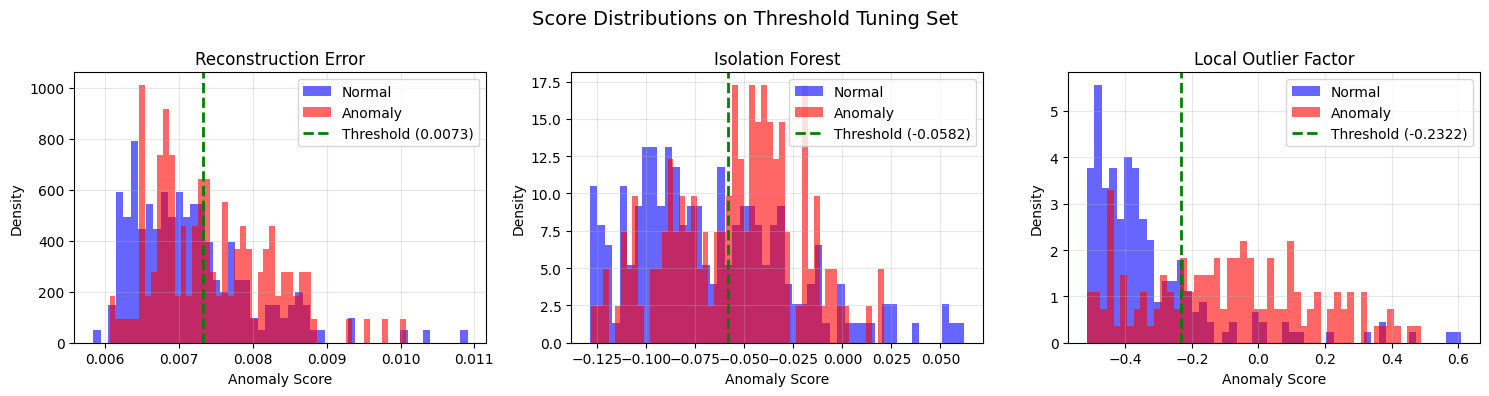

Saved artifact: outputs/notebook_runs/20260620_212421/metrics/convae_threshold_tuning_metrics.json


PosixPath('outputs/notebook_runs/20260620_212421/metrics/convae_threshold_tuning_metrics.json')

In [27]:
# Visualize score distributions on threshold tuning set
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_score_distributions(recon_file_normal, recon_file_anomaly, thresh_recon, 
                        "Reconstruction Error", axes[0])
plot_score_distributions(if_file_normal, if_file_anomaly, thresh_if,
                        "Isolation Forest", axes[1])
plot_score_distributions(lof_file_normal, lof_file_anomaly, thresh_lof,
                        "Local Outlier Factor", axes[2])

plt.suptitle("Score Distributions on Threshold Tuning Set", fontsize=14)
plt.tight_layout()
save_figure(fig, "convae_threshold_tuning_distributions")
plt.show()
save_json_artifact({
    "ConvAE Reconstruction Error": metrics_recon,
    "ConvAE + Isolation Forest": metrics_if,
    "ConvAE + LOF": metrics_lof,
}, "convae_threshold_tuning_metrics")

## 10. ConvAE Final Evaluation

Evaluate the ConvAE-based methods on the held-out test set (50% test-normal + 70% anomaly).

In [28]:
# Process final test data
test_normal_specs, test_normal_meta = load_or_process(
    "test_normal", splits['test_normal'], preprocess_config, DATA_PROCESSED
)
test_anomaly_specs, test_anomaly_meta = load_or_process(
    "test_anomaly", splits['test_anomaly'], preprocess_config, DATA_PROCESSED
)

print(f"Final test - Normal:  {test_normal_specs.shape}")
print(f"Final test - Anomaly: {test_anomaly_specs.shape}")

# Create dataloaders
test_normal_dataset = SpectrogramDataset(test_normal_specs)
test_anomaly_dataset = SpectrogramDataset(test_anomaly_specs)

test_normal_loader = DataLoader(test_normal_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_anomaly_loader = DataLoader(test_anomaly_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Migrated test_normal cached metadata with source_id; spectrogram cache reused.
Migrated test_anomaly cached metadata with source_id; spectrogram cache reused.
Final test - Normal:  (1800, 128, 64)
Final test - Anomaly: (2880, 128, 64)


In [29]:
# Extract latent representations for test data (ConvAE)
print("Extracting ConvAE features from test data...")
latent_test_normal = extract_latent_representations(model, test_normal_loader, device)
latent_test_anomaly = extract_latent_representations(model, test_anomaly_loader, device)

# Compute ConvAE-based scores
print("Computing ConvAE anomaly scores...")

# Reconstruction Error
recon_scores_test_normal = extract_reconstruction_errors(model, test_normal_loader, device)
recon_scores_test_anomaly = extract_reconstruction_errors(model, test_anomaly_loader, device)

# Isolation Forest (negate: higher = more anomalous)
if_scores_test_normal = -iforest.decision_function(latent_test_normal)
if_scores_test_anomaly = -iforest.decision_function(latent_test_anomaly)

# LOF (negate: higher = more anomalous)
lof_scores_test_normal = -lof.decision_function(latent_test_normal)
lof_scores_test_anomaly = -lof.decision_function(latent_test_anomaly)

print("Done!")

Extracting ConvAE features from test data...
Computing ConvAE anomaly scores...
Done!


In [30]:
# Aggregate test scores to file level (using same strategy as tuning)

# Reconstruction Error
recon_test_file_normal, _ = aggregate_scores_to_files(
    recon_scores_test_normal, test_normal_meta, strategy=AGGREGATION_STRATEGY
)
recon_test_file_anomaly, _ = aggregate_scores_to_files(
    recon_scores_test_anomaly, test_anomaly_meta, strategy=AGGREGATION_STRATEGY
)

# Isolation Forest
if_test_file_normal, _ = aggregate_scores_to_files(
    if_scores_test_normal, test_normal_meta, strategy=AGGREGATION_STRATEGY
)
if_test_file_anomaly, _ = aggregate_scores_to_files(
    if_scores_test_anomaly, test_anomaly_meta, strategy=AGGREGATION_STRATEGY
)

# LOF
lof_test_file_normal, _ = aggregate_scores_to_files(
    lof_scores_test_normal, test_normal_meta, strategy=AGGREGATION_STRATEGY
)
lof_test_file_anomaly, _ = aggregate_scores_to_files(
    lof_scores_test_anomaly, test_anomaly_meta, strategy=AGGREGATION_STRATEGY
)

print(f"Test set file counts - Normal: {len(recon_test_file_normal)}, Anomaly: {len(recon_test_file_anomaly)}")

Test set file counts - Normal: 200, Anomaly: 320


In [31]:
# Evaluate each method using thresholds from tuning set
results_recon = attach_protocol(
    evaluate_detection(recon_test_file_normal, recon_test_file_anomaly, thresh_recon),
    "ConvAE Reconstruction Error", THRESHOLD_METRIC, AGGREGATION_STRATEGY, metrics_recon,
)
print_results(results_recon, "ConvAE Reconstruction Error")

results_if = attach_protocol(
    evaluate_detection(if_test_file_normal, if_test_file_anomaly, thresh_if),
    "ConvAE + Isolation Forest", THRESHOLD_METRIC, AGGREGATION_STRATEGY, metrics_if,
)
print_results(results_if, "ConvAE + Isolation Forest")

results_lof = attach_protocol(
    evaluate_detection(lof_test_file_normal, lof_test_file_anomaly, thresh_lof),
    "ConvAE + LOF", THRESHOLD_METRIC, AGGREGATION_STRATEGY, metrics_lof,
)
print_results(results_lof, "ConvAE + LOF")

save_json_artifact({
    "ConvAE Reconstruction Error": results_recon,
    "ConvAE + Isolation Forest": results_if,
    "ConvAE + LOF": results_lof,
}, "convae_individual_test_results")


====== ConvAE Reconstruction Error Results =======
  Threshold:    0.007329
  Accuracy:     0.5750
  Bal Accuracy: 0.5947
  Precision:    0.7181
  Recall:       0.5094
  F1 Score:     0.5960
  AUC-ROC:      0.6462
  AUC-PR:       0.7221

  Confusion Matrix:
                 Pred Normal  Pred Anomaly
    True Normal        136            64
    True Anomaly       157           163


======= ConvAE + Isolation Forest Results ========
  Threshold:    -0.058192
  Accuracy:     0.5635
  Bal Accuracy: 0.5600
  Precision:    0.6691
  Recall:       0.5750
  F1 Score:     0.6185
  AUC-ROC:      0.6009
  AUC-PR:       0.7015

  Confusion Matrix:
                 Pred Normal  Pred Anomaly
    True Normal        109            91
    True Anomaly       136           184


============== ConvAE + LOF Results ==============
  Threshold:    -0.232232
  Accuracy:     0.7231
  Bal Accuracy: 0.7328
  Precision:    0.8308
  Recall:       0.6906
  F1 Score:     0.7543
  AUC-ROC:      0.7880
  AUC-PR:    

PosixPath('outputs/notebook_runs/20260620_212421/metrics/convae_individual_test_results.json')

## 11. ConvAE Method Comparison

Compare the performance of the three ConvAE-based anomaly detection methods.

In [32]:
# Create results dictionary for comparison
results_dict = {
    'ConvAE Recon Error': results_recon,
    'ConvAE + IF': results_if,
    'ConvAE + LOF': results_lof
}

# Print comparison table
print("\n" + "="*90)
print(" CONVAE FINAL TEST SET RESULTS ".center(90, "="))
print("="*90 + "\n")
convae_table = save_comparison_table(results_dict, "convae_final_test_results")
print(convae_table)


============================= CONVAE FINAL TEST SET RESULTS ==============================

Saved artifact: outputs/notebook_runs/20260620_212421/tables/convae_final_test_results.txt
Saved artifact: outputs/notebook_runs/20260620_212421/tables/convae_final_test_results.csv
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/convae_final_test_results.json
Method                      Accuracy    Bal Acc  Precision     Recall         F1    AUC-ROC     AUC-PR
------------------------------------------------------------------------------------------------------
ConvAE Recon Error            0.5750     0.5947     0.7181     0.5094     0.5960     0.6462     0.7221
ConvAE + IF                   0.5635     0.5600     0.6691     0.5750     0.6185     0.6009     0.7015
ConvAE + LOF                  0.7231     0.7328     0.8308     0.6906     0.7543     0.7880     0.8520


Saved figure: outputs/notebook_runs/20260620_212421/figures/convae_roc_comparison.png


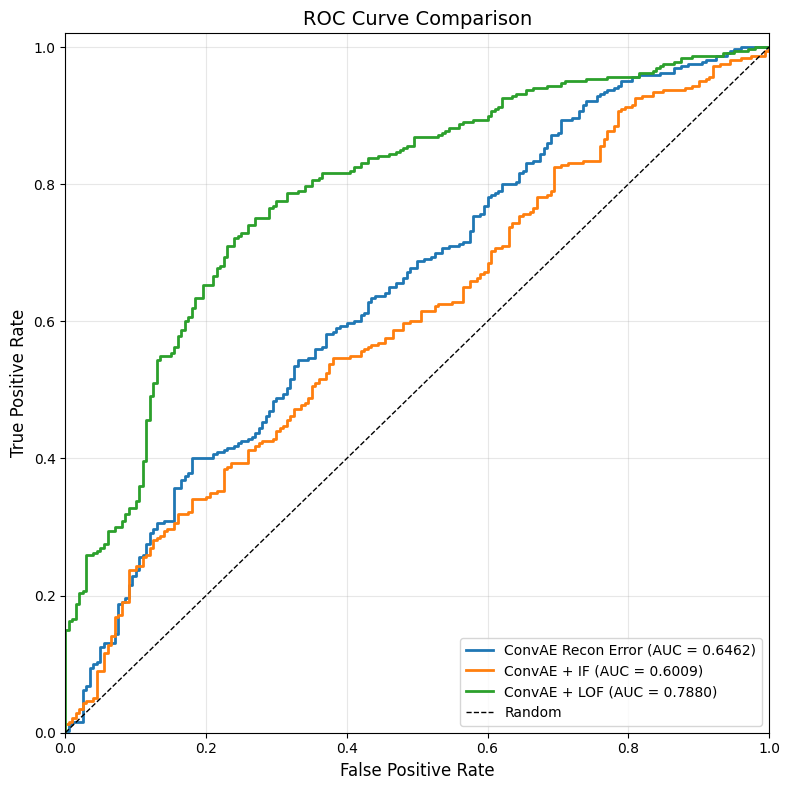

In [33]:
# Plot ROC curves comparison
fig, ax = plot_comparison_roc(results_dict)
save_figure(fig, "convae_roc_comparison")
plt.show()

Saved figure: outputs/notebook_runs/20260620_212421/figures/convae_confusion_matrices.png


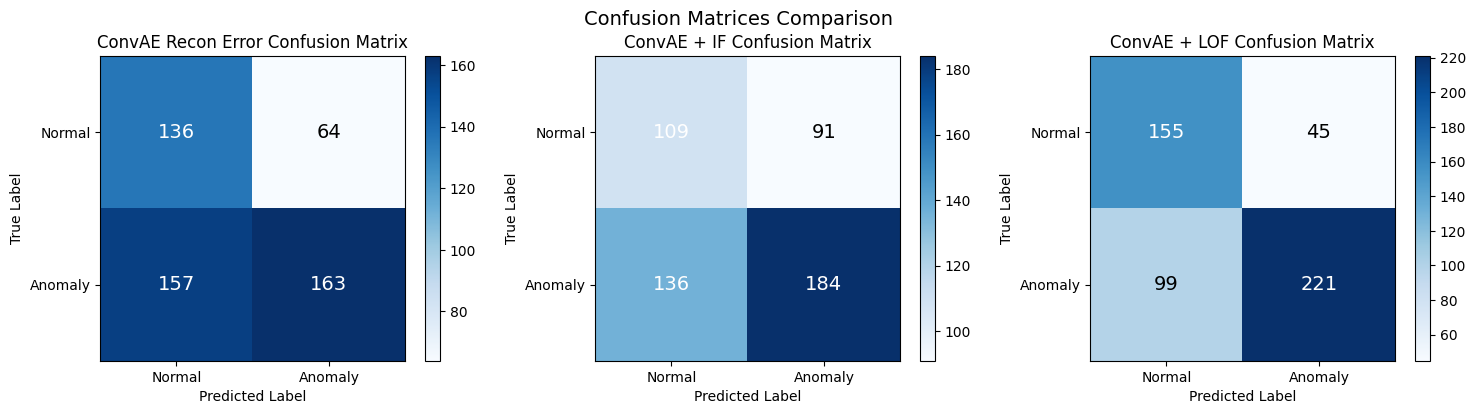

In [34]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, results) in zip(axes, results_dict.items()):
    plot_confusion_matrix(results, name, ax)

plt.suptitle("Confusion Matrices Comparison", fontsize=14)
plt.tight_layout()
save_figure(fig, "convae_confusion_matrices")
plt.show()

Saved figure: outputs/notebook_runs/20260620_212421/figures/convae_final_score_distributions.png


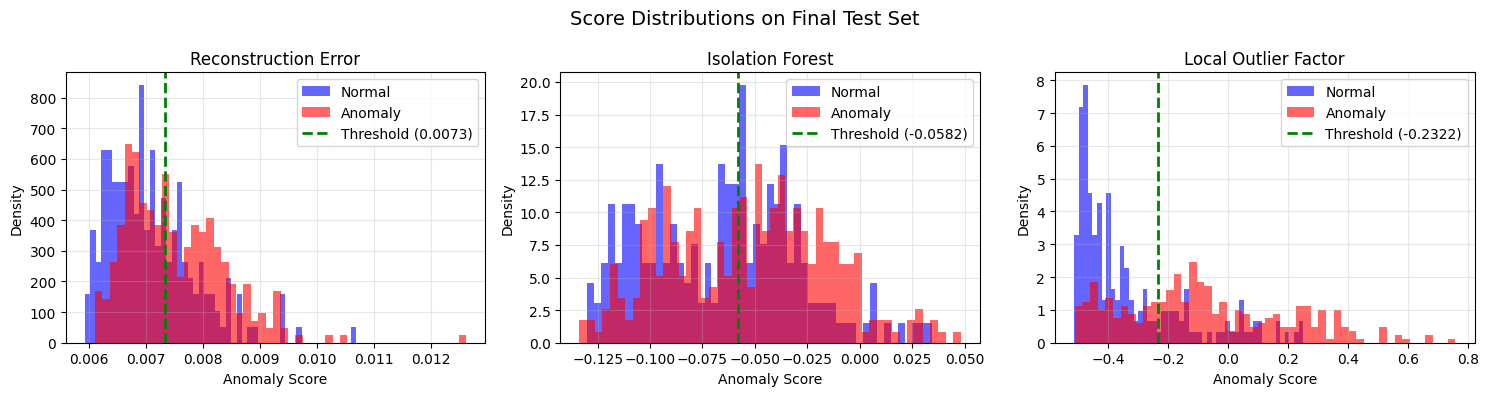

In [35]:
# Score distributions on final test set
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_score_distributions(recon_test_file_normal, recon_test_file_anomaly, thresh_recon,
                        "Reconstruction Error", axes[0])
plot_score_distributions(if_test_file_normal, if_test_file_anomaly, thresh_if,
                        "Isolation Forest", axes[1])
plot_score_distributions(lof_test_file_normal, lof_test_file_anomaly, thresh_lof,
                        "Local Outlier Factor", axes[2])

plt.suptitle("Score Distributions on Final Test Set", fontsize=14)
plt.tight_layout()
save_figure(fig, "convae_final_score_distributions")
plt.show()

### 11.1 Summary

The three ConvAE-based methods provide different perspectives on anomaly detection:

1. **ConvAE Reconstruction Error** measures how well the normal-only autoencoder reconstructs each file.
2. **ConvAE + Isolation Forest** detects points that are easy to isolate in latent space.
3. **ConvAE + Local Outlier Factor** detects low local-density regions in latent space.

Key protocol points:
- All metrics are **file-level** after aggregating window scores with `AGGREGATION_STRATEGY`.
- Thresholded metrics use `THRESHOLD_METRIC = "balanced_accuracy"` on the tuning split.
- AUC-ROC and AUC-PR are threshold-independent; confusion matrices depend on the selected threshold policy.

## 12. Classical Detectors on the ConvAE Latent Space

These methods reuse the frozen ConvAE latent representation. OC-SVM remains normal-only. Supervised SVM and XGBoost use the labelled threshold split as training data, so they are reported separately from the unsupervised methods. Their cross-validation is grouped by `source_id` so windows from the same file never appear in both train and validation folds.

In [36]:
from src.models.classical import (
    fit_oc_svm, score_oc_svm,
    fit_svm_supervised, score_svm_supervised,
    fit_xgboost, score_xgboost,
    compute_mfcc_features_batch,
)

latent_ifthr_all = np.concatenate([latent_tune_normal, latent_tune_anomaly], axis=0)
y_ifthr_all = np.concatenate([
    np.zeros(len(latent_tune_normal), dtype=int),
    np.ones(len(latent_tune_anomaly), dtype=int),
])
groups_ifthr_all = np.concatenate([
    groups_from_metadata(tune_normal_meta),
    groups_from_metadata(tune_anomaly_meta),
])

print(f"Supervised latent training set: X={latent_ifthr_all.shape}, anomaly fraction={y_ifthr_all.mean():.2%}")
print(f"Grouped CV source files: {len(np.unique(groups_ifthr_all))}")

Supervised latent training set: X=(3024, 64), anomaly fraction=40.48%
Grouped CV source files: 336


In [37]:
def evaluate_window_score_method(name, score_fn, tune_X_normal, tune_X_anomaly, test_X_normal, test_X_anomaly, tune_meta_normal, tune_meta_anomaly, test_meta_normal, test_meta_anomaly, aggregation=AGGREGATION_STRATEGY, threshold_metric=THRESHOLD_METRIC):
    """Score windows, aggregate to file level, tune threshold, and evaluate."""
    tune_scores_normal = score_fn(tune_X_normal)
    tune_scores_anomaly = score_fn(tune_X_anomaly)
    tune_file_normal, _ = aggregate_scores_to_files(tune_scores_normal, tune_meta_normal, strategy=aggregation)
    tune_file_anomaly, _ = aggregate_scores_to_files(tune_scores_anomaly, tune_meta_anomaly, strategy=aggregation)
    threshold, tune_metrics = find_optimal_threshold(tune_file_normal, tune_file_anomaly, metric=threshold_metric)

    test_scores_normal = score_fn(test_X_normal)
    test_scores_anomaly = score_fn(test_X_anomaly)
    test_file_normal, _ = aggregate_scores_to_files(test_scores_normal, test_meta_normal, strategy=aggregation)
    test_file_anomaly, _ = aggregate_scores_to_files(test_scores_anomaly, test_meta_anomaly, strategy=aggregation)

    results = evaluate_detection(test_file_normal, test_file_anomaly, threshold)
    return attach_protocol(results, name, threshold_metric, aggregation, tune_metrics)

In [38]:
best_ocsvm = {"nu": None, "balanced_accuracy": -1, "model": None, "scaler": None, "tune_metrics": None}
for nu in [0.05, 0.1, 0.2]:
    candidate_model, candidate_scaler = fit_oc_svm(latent_train, nu=nu, gamma="scale")
    score_fn = lambda X, m=candidate_model, sc=candidate_scaler: score_oc_svm(m, sc, X)
    tune_n = score_fn(latent_tune_normal)
    tune_a = score_fn(latent_tune_anomaly)
    file_n, _ = aggregate_scores_to_files(tune_n, tune_normal_meta, strategy=AGGREGATION_STRATEGY)
    file_a, _ = aggregate_scores_to_files(tune_a, tune_anomaly_meta, strategy=AGGREGATION_STRATEGY)
    _, tune_metrics = find_optimal_threshold(file_n, file_a, metric=THRESHOLD_METRIC)
    print(f"nu={nu}: tune BA={tune_metrics['balanced_accuracy']:.4f}")
    if tune_metrics["balanced_accuracy"] > best_ocsvm["balanced_accuracy"]:
        best_ocsvm.update({"nu": nu, "balanced_accuracy": tune_metrics["balanced_accuracy"], "model": candidate_model, "scaler": candidate_scaler, "tune_metrics": tune_metrics})

ocsvm_model, ocsvm_scaler = best_ocsvm["model"], best_ocsvm["scaler"]
print(f"Best nu={best_ocsvm['nu']}")

results_ocsvm = evaluate_window_score_method(
    "OC-SVM (AE latent)",
    lambda X: score_oc_svm(ocsvm_model, ocsvm_scaler, X),
    latent_tune_normal, latent_tune_anomaly,
    latent_test_normal, latent_test_anomaly,
    tune_normal_meta, tune_anomaly_meta,
    test_normal_meta, test_anomaly_meta,
)
print_results(results_ocsvm, "OC-SVM (AE latent)")

nu=0.05: tune BA=0.6141
nu=0.1: tune BA=0.6191
nu=0.2: tune BA=0.6201
Best nu=0.2

=========== OC-SVM (AE latent) Results ===========
  Threshold:    -92.210511
  Accuracy:     0.5769
  Bal Accuracy: 0.5447
  Precision:    0.6479
  Recall:       0.6844
  F1 Score:     0.6657
  AUC-ROC:      0.6148
  AUC-PR:       0.7155

  Confusion Matrix:
                 Pred Normal  Pred Anomaly
    True Normal         81           119
    True Anomaly       101           219



In [39]:
svm_model, svm_info = fit_svm_supervised(latent_ifthr_all, y_ifthr_all, groups=groups_ifthr_all, cv=5, random_state=SEED)
print("SVM grouped CV:", svm_info)

results_svm = evaluate_window_score_method(
    "SVM-sup (AE latent)",
    lambda X: score_svm_supervised(svm_model, X),
    latent_tune_normal, latent_tune_anomaly,
    latent_test_normal, latent_test_anomaly,
    tune_normal_meta, tune_anomaly_meta,
    test_normal_meta, test_anomaly_meta,
)
print_results(results_svm, "SVM-sup (AE latent)")

SVM grouped CV: {'best_params': {'svc__C': 1.0, 'svc__gamma': 'scale'}, 'best_cv_score': 0.9464263311493063, 'cv_splits': 5, 'n_groups': 336, 'grouped_cv': True, 'scoring': 'roc_auc'}

========== SVM-sup (AE latent) Results ===========
  Threshold:    0.804182
  Accuracy:     0.7885
  Bal Accuracy: 0.8272
  Precision:    0.9953
  Recall:       0.6594
  F1 Score:     0.7932
  AUC-ROC:      0.9533
  AUC-PR:       0.9715

  Confusion Matrix:
                 Pred Normal  Pred Anomaly
    True Normal        199             1
    True Anomaly       109           211



In [40]:
xgb_model, xgb_info = fit_xgboost(latent_ifthr_all, y_ifthr_all, groups=groups_ifthr_all, cv=5, random_state=SEED)
print("XGBoost grouped CV:", xgb_info)

results_xgb = evaluate_window_score_method(
    "XGBoost (AE latent)",
    lambda X: score_xgboost(xgb_model, X),
    latent_tune_normal, latent_tune_anomaly,
    latent_test_normal, latent_test_anomaly,
    tune_normal_meta, tune_anomaly_meta,
    test_normal_meta, test_anomaly_meta,
)
print_results(results_xgb, "XGBoost (AE latent)")

XGBoost grouped CV: {'best_params': {'learning_rate': 0.1, 'max_depth': 3}, 'best_cv_score': 0.9398535644154433, 'cv_splits': 5, 'n_groups': 336, 'grouped_cv': True, 'scale_pos_weight': 1.4705882352941178, 'scoring': 'roc_auc'}

========== XGBoost (AE latent) Results ===========
  Threshold:    0.678353
  Accuracy:     0.7923
  Bal Accuracy: 0.8266
  Precision:    0.9775
  Recall:       0.6781
  F1 Score:     0.8007
  AUC-ROC:      0.9413
  AUC-PR:       0.9646

  Confusion Matrix:
                 Pred Normal  Pred Anomaly
    True Normal        195             5
    True Anomaly       103           217



### 12.1 MFCC Sanity Baseline

MFCC statistics bypass the ConvAE and therefore are not the core assignment method. They are useful as a sanity baseline: if a simple hand-crafted representation wins, the result should be discussed honestly.

In [41]:
MFCC_CACHE = LATENTS_CACHE / "mfcc"
MFCC_CACHE.mkdir(exist_ok=True)


def mfcc_for(name, specs):
    path = MFCC_CACHE / f"{name}.npy"
    if path.exists():
        return np.load(path)
    features = compute_mfcc_features_batch(specs, n_mfcc=13, config=preprocess_config)
    np.save(path, features)
    return features

M_tune_normal = mfcc_for("tune_normal", tune_normal_specs)
M_tune_anomaly = mfcc_for("tune_anomaly", tune_anomaly_specs)
M_test_normal = mfcc_for("test_normal", test_normal_specs)
M_test_anomaly = mfcc_for("test_anomaly", test_anomaly_specs)

X_mfcc = np.concatenate([M_tune_normal, M_tune_anomaly], axis=0)
y_mfcc = y_ifthr_all.copy()
groups_mfcc = groups_ifthr_all.copy()

mfcc_svm, mfcc_info = fit_svm_supervised(X_mfcc, y_mfcc, groups=groups_mfcc, cv=5, random_state=SEED)
print("MFCC SVM grouped CV:", mfcc_info)

results_mfcc = evaluate_window_score_method(
    "SVM-sup (MFCC stats)",
    lambda X: score_svm_supervised(mfcc_svm, X),
    M_tune_normal, M_tune_anomaly,
    M_test_normal, M_test_anomaly,
    tune_normal_meta, tune_anomaly_meta,
    test_normal_meta, test_anomaly_meta,
)
print_results(results_mfcc, "SVM-sup (MFCC stats)")

MFCC SVM grouped CV: {'best_params': {'svc__C': 1.0, 'svc__gamma': 'auto'}, 'best_cv_score': 0.9088055628781314, 'cv_splits': 5, 'n_groups': 336, 'grouped_cv': True, 'scoring': 'roc_auc'}

========== SVM-sup (MFCC stats) Results ==========
  Threshold:    0.505611
  Accuracy:     0.8423
  Bal Accuracy: 0.8541
  Precision:    0.9312
  Recall:       0.8031
  F1 Score:     0.8624
  AUC-ROC:      0.9340
  AUC-PR:       0.9590

  Confusion Matrix:
                 Pred Normal  Pred Anomaly
    True Normal        181            19
    True Anomaly        63           257



In [42]:
classical_results_dict = {
    "OC-SVM (AE latent)": results_ocsvm,
    "SVM-sup (AE latent)": results_svm,
    "XGBoost (AE latent)": results_xgb,
    "SVM-sup (MFCC stats)": results_mfcc,
}

classical_table = save_comparison_table(classical_results_dict, "classical_final_test_results")
print(classical_table)

Saved artifact: outputs/notebook_runs/20260620_212421/tables/classical_final_test_results.txt
Saved artifact: outputs/notebook_runs/20260620_212421/tables/classical_final_test_results.csv
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/classical_final_test_results.json
Method                      Accuracy    Bal Acc  Precision     Recall         F1    AUC-ROC     AUC-PR
------------------------------------------------------------------------------------------------------
OC-SVM (AE latent)            0.5769     0.5447     0.6479     0.6844     0.6657     0.6148     0.7155
SVM-sup (AE latent)           0.7885     0.8272     0.9953     0.6594     0.7932     0.9533     0.9715
XGBoost (AE latent)           0.7923     0.8266     0.9775     0.6781     0.8007     0.9413     0.9646
SVM-sup (MFCC stats)          0.8423     0.8541     0.9312     0.8031     0.8624     0.9340     0.9590


## 13. Optional PANNs Final Evaluation

Evaluate the PANNs-based methods only when cached embeddings or a configured `PANNS_CHECKPOINT_PATH` are available.

In [43]:
# Compute PANNs-based scores on test set
if panns_available:
    print("Computing PANNs anomaly scores on test set...")
    panns_lof_test_normal = -lof_panns.decision_function(panns_test_normal)
    panns_lof_test_anomaly = -lof_panns.decision_function(panns_test_anomaly)
    panns_if_test_normal = -iforest_panns.decision_function(panns_test_normal)
    panns_if_test_anomaly = -iforest_panns.decision_function(panns_test_anomaly)

    panns_lof_test_file_normal, _ = aggregate_scores_to_files(panns_lof_test_normal, panns_test_normal_meta, strategy=PANNS_AGG_STRATEGY)
    panns_lof_test_file_anomaly, _ = aggregate_scores_to_files(panns_lof_test_anomaly, panns_test_anomaly_meta, strategy=PANNS_AGG_STRATEGY)
    panns_if_test_file_normal, _ = aggregate_scores_to_files(panns_if_test_normal, panns_test_normal_meta, strategy=PANNS_AGG_STRATEGY)
    panns_if_test_file_anomaly, _ = aggregate_scores_to_files(panns_if_test_anomaly, panns_test_anomaly_meta, strategy=PANNS_AGG_STRATEGY)

    print(f"PANNs test files - Normal: {len(panns_lof_test_file_normal)}, Anomaly: {len(panns_lof_test_file_anomaly)}")
else:
    print("Skipping PANNs final scoring because embeddings are unavailable.")

Skipping PANNs final scoring because embeddings are unavailable.


In [44]:
# Evaluate PANNs methods
if panns_available:
    results_panns_lof = attach_protocol(
        evaluate_detection(panns_lof_test_file_normal, panns_lof_test_file_anomaly, thresh_panns_lof),
        "PANNs + LOF", THRESHOLD_METRIC, PANNS_AGG_STRATEGY, tune_panns_lof,
    )
    print_results(results_panns_lof, "PANNs + LOF")

    results_panns_if = attach_protocol(
        evaluate_detection(panns_if_test_file_normal, panns_if_test_file_anomaly, thresh_panns_if),
        "PANNs + IF", THRESHOLD_METRIC, PANNS_AGG_STRATEGY, tune_panns_if,
    )
    print_results(results_panns_if, "PANNs + IF")
else:
    results_panns_lof = None
    results_panns_if = None

In [45]:
# PANNs results comparison table
if panns_available:
    panns_results_dict = {
        "PANNs + LOF": results_panns_lof,
        "PANNs + IF": results_panns_if,
    }

    print("\n" + "="*90)
    print(" PANNS FINAL TEST SET RESULTS ".center(90, "="))
    print("="*90 + "\n")
    panns_table = save_comparison_table(panns_results_dict, "panns_final_test_results")
    print(panns_table)

    fig, ax = plot_comparison_roc(panns_results_dict)
    ax.set_title("PANNs ROC Curve Comparison", fontsize=14)
    save_figure(fig, "panns_roc_comparison")
    plt.show()
else:
    panns_results_dict = {}

In [46]:
# PANNs confusion matrices
if panns_available:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (name, results) in zip(axes, panns_results_dict.items()):
        plot_confusion_matrix(results, name, ax)
    plt.suptitle("PANNs Confusion Matrices", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "panns_confusion_matrices")
    plt.show()

In [47]:
# PANNs score distributions on final test set
if panns_available:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_score_distributions(panns_lof_test_file_normal, panns_lof_test_file_anomaly, thresh_panns_lof, "PANNs + LOF", axes[0])
    plot_score_distributions(panns_if_test_file_normal, panns_if_test_file_anomaly, thresh_panns_if, "PANNs + IF", axes[1])
    plt.suptitle("PANNs Score Distributions on Final Test Set", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "panns_final_score_distributions")
    plt.show()

## 14. Cross-Method Comparison

Compare the assignment-focused ConvAE latent methods, supervised latent classifiers, MFCC sanity baseline, and optional PANNs baseline when available.

In [48]:
# Combined comparison table (all available methods)
all_results_dict = dict(results_dict)
all_results_dict.update(classical_results_dict)
if panns_results_dict:
    all_results_dict.update(panns_results_dict)

print("\n" + "="*100)
print(" ALL METHODS - FINAL TEST SET RESULTS ".center(100, "="))
print("="*100 + "\n")
all_methods_table = save_comparison_table(all_results_dict, "all_methods_final_test_results")
print(all_methods_table)


=============================== ALL METHODS - FINAL TEST SET RESULTS ===============================

Saved artifact: outputs/notebook_runs/20260620_212421/tables/all_methods_final_test_results.txt
Saved artifact: outputs/notebook_runs/20260620_212421/tables/all_methods_final_test_results.csv
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/all_methods_final_test_results.json
Method                      Accuracy    Bal Acc  Precision     Recall         F1    AUC-ROC     AUC-PR
------------------------------------------------------------------------------------------------------
ConvAE Recon Error            0.5750     0.5947     0.7181     0.5094     0.5960     0.6462     0.7221
ConvAE + IF                   0.5635     0.5600     0.6691     0.5750     0.6185     0.6009     0.7015
ConvAE + LOF                  0.7231     0.7328     0.8308     0.6906     0.7543     0.7880     0.8520
OC-SVM (AE latent)            0.5769     0.5447     0.6479     0.6844     0.6657     0.6148 

Saved figure: outputs/notebook_runs/20260620_212421/figures/all_methods_roc_comparison.png


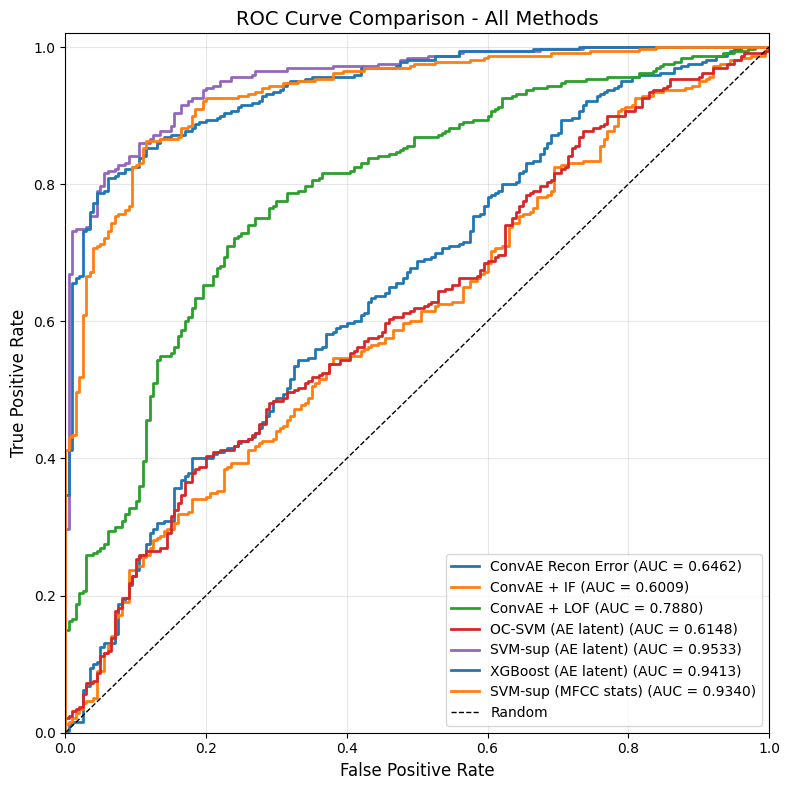

In [49]:
# Combined ROC curves (all methods)
fig, ax = plot_comparison_roc(all_results_dict)
ax.set_title("ROC Curve Comparison - All Methods", fontsize=14)
save_figure(fig, "all_methods_roc_comparison")
plt.show()

Saved figure: outputs/notebook_runs/20260620_212421/figures/all_methods_confusion_matrices.png


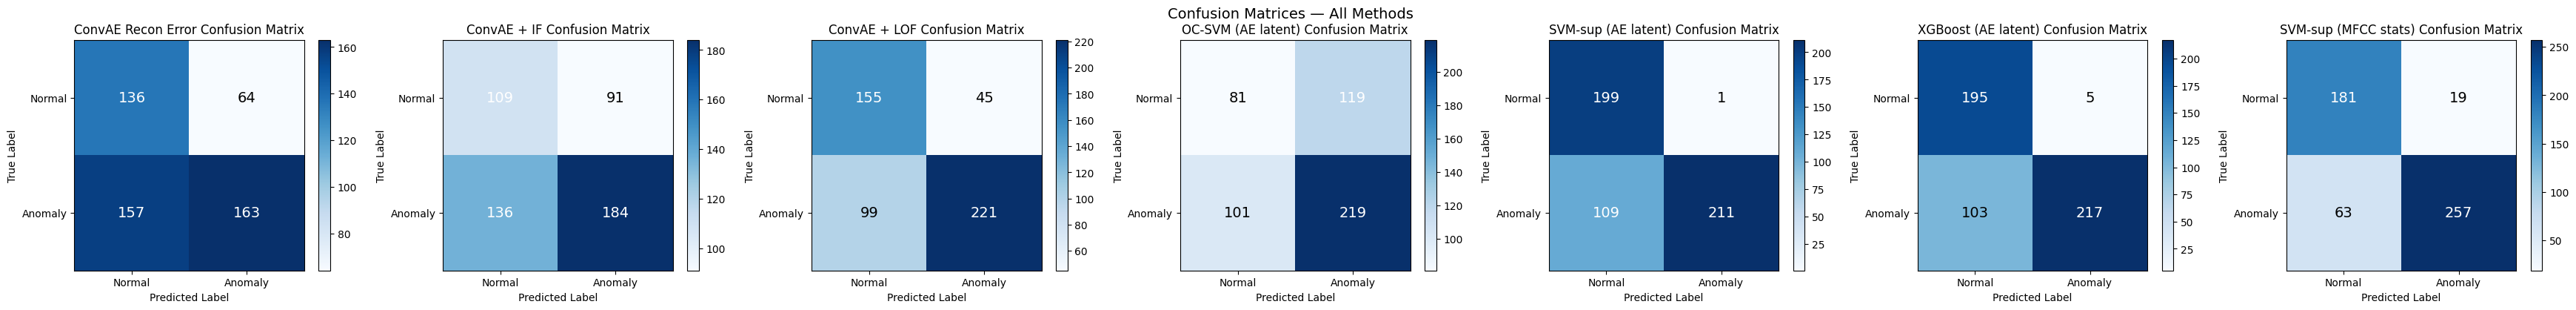

In [50]:
# Combined confusion matrices (all methods)
n_methods = len(all_results_dict)
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 4))

for ax, (name, results) in zip(axes, all_results_dict.items()):
    plot_confusion_matrix(results, name, ax)

plt.suptitle("Confusion Matrices — All Methods", fontsize=14)
plt.tight_layout()
save_figure(fig, "all_methods_confusion_matrices")
plt.show()

Saved figure: outputs/notebook_runs/20260620_212421/figures/all_methods_final_score_distributions.png


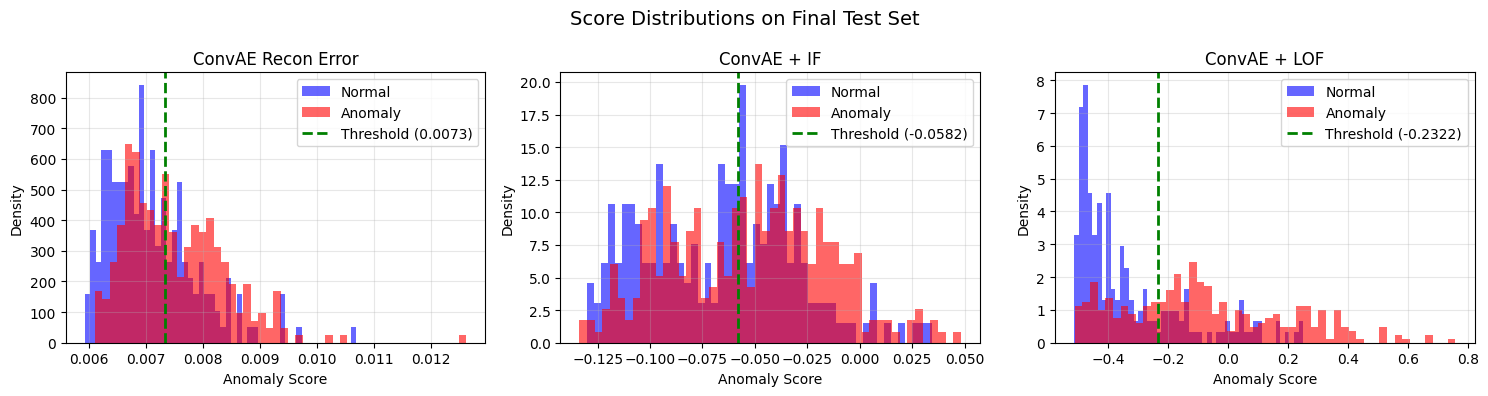

In [51]:
# Combined score distributions (core ConvAE methods plus optional PANNs)
score_data = [
    (recon_test_file_normal, recon_test_file_anomaly, thresh_recon, "ConvAE Recon Error"),
    (if_test_file_normal, if_test_file_anomaly, thresh_if, "ConvAE + IF"),
    (lof_test_file_normal, lof_test_file_anomaly, thresh_lof, "ConvAE + LOF"),
]
if panns_available:
    score_data.extend([
        (panns_lof_test_file_normal, panns_lof_test_file_anomaly, thresh_panns_lof, "PANNs + LOF"),
        (panns_if_test_file_normal, panns_if_test_file_anomaly, thresh_panns_if, "PANNs + IF"),
    ])

fig, axes = plt.subplots(1, len(score_data), figsize=(5 * len(score_data), 4))
if len(score_data) == 1:
    axes = [axes]
for ax, (s_normal, s_anomaly, thresh, title) in zip(axes, score_data):
    plot_score_distributions(s_normal, s_anomaly, thresh, title, ax)
plt.suptitle("Score Distributions on Final Test Set", fontsize=14)
plt.tight_layout()
save_figure(fig, "all_methods_final_score_distributions")
plt.show()

### 14.1 Optional PANNs Baseline

PANNs CNN14 is an optional sanity baseline. It is useful for checking whether a large pretrained audio representation separates the data much better than the custom ConvAE latent space. It is not required for the assignment-focused pipeline and is skipped automatically when cached embeddings or `PANNS_CHECKPOINT_PATH` are unavailable.

In [52]:
# Optional sensitivity check: LOF aggregation + threshold strategies
from itertools import product

strategies = ['max', 'mean', 'percentile_90', 'median']
metrics_to_optimize = ['balanced_accuracy', 'f1', 'accuracy']

best_config = None
best_tnr = 0

for strat, metric in product(strategies, metrics_to_optimize):
    # Aggregate tuning scores
    n_file, _ = aggregate_scores_to_files(lof_scores_tune_normal, tune_normal_meta, strategy=strat)
    a_file, _ = aggregate_scores_to_files(lof_scores_tune_anomaly, tune_anomaly_meta, strategy=strat)
    
    # Find threshold
    thresh, m = find_optimal_threshold(n_file, a_file, metric=metric)
    
    # Evaluate on test
    n_test, _ = aggregate_scores_to_files(lof_scores_test_normal, test_normal_meta, strategy=strat)
    a_test, _ = aggregate_scores_to_files(lof_scores_test_anomaly, test_anomaly_meta, strategy=strat)
    
    results = evaluate_detection(n_test, a_test, thresh)
    tnr = results['confusion_matrix'][0,0] / results['confusion_matrix'][0,:].sum()
    
    print(f"{strat:>15} + {metric:>18}: BA={results['balanced_accuracy']:.3f}, F1={results['f1']:.3f}, TNR={tnr:.3f}, TPR={results['recall']:.3f}")
    
    if tnr > best_tnr and results['f1'] > 0.5:
        best_tnr = tnr
        best_config = (strat, metric, thresh)

print(f"\nBest config: {best_config}")


            max +  balanced_accuracy: BA=0.722, F1=0.750, TNR=0.750, TPR=0.694
            max +                 f1: BA=0.725, F1=0.758, TNR=0.740, TPR=0.709
            max +           accuracy: BA=0.701, F1=0.707, TNR=0.780, TPR=0.622
           mean +  balanced_accuracy: BA=0.733, F1=0.754, TNR=0.775, TPR=0.691
           mean +                 f1: BA=0.733, F1=0.754, TNR=0.775, TPR=0.691
           mean +           accuracy: BA=0.733, F1=0.754, TNR=0.775, TPR=0.691
  percentile_90 +  balanced_accuracy: BA=0.728, F1=0.765, TNR=0.735, TPR=0.722
  percentile_90 +                 f1: BA=0.728, F1=0.765, TNR=0.735, TPR=0.722
  percentile_90 +           accuracy: BA=0.725, F1=0.750, TNR=0.760, TPR=0.691
         median +  balanced_accuracy: BA=0.732, F1=0.751, TNR=0.780, TPR=0.684
         median +                 f1: BA=0.732, F1=0.751, TNR=0.780, TPR=0.684
         median +           accuracy: BA=0.735, F1=0.749, TNR=0.795, TPR=0.675

Best config: ('median', 'accuracy', np.float32(-0.2

In [53]:
# Optional sensitivity check: IF aggregation + threshold strategies
from itertools import product

strategies = ['max', 'mean', 'percentile_90', 'median']
metrics_to_optimize = ['balanced_accuracy', 'f1', 'accuracy']

best_config = None
best_tnr = 0

for strat, metric in product(strategies, metrics_to_optimize):
    # Aggregate tuning scores
    n_file, _ = aggregate_scores_to_files(if_scores_tune_normal, tune_normal_meta, strategy=strat)
    a_file, _ = aggregate_scores_to_files(if_scores_tune_anomaly, tune_anomaly_meta, strategy=strat)
    
    # Find threshold
    thresh, m = find_optimal_threshold(n_file, a_file, metric=metric)
    
    # Evaluate on test
    n_test, _ = aggregate_scores_to_files(if_scores_test_normal, test_normal_meta, strategy=strat)
    a_test, _ = aggregate_scores_to_files(if_scores_test_anomaly, test_anomaly_meta, strategy=strat)
    
    results = evaluate_detection(n_test, a_test, thresh)
    tnr = results['confusion_matrix'][0,0] / results['confusion_matrix'][0,:].sum()
    
    print(f"{strat:>15} + {metric:>18}: BA={results['balanced_accuracy']:.3f}, F1={results['f1']:.3f}, TNR={tnr:.3f}, TPR={results['recall']:.3f}")
    
    if tnr > best_tnr and results['f1'] > 0.5:
        best_tnr = tnr
        best_config = (strat, metric, thresh)

print(f"\nBest config: {best_config}")


            max +  balanced_accuracy: BA=0.542, F1=0.673, TNR=0.380, TPR=0.703
            max +                 f1: BA=0.556, F1=0.690, TNR=0.380, TPR=0.731
            max +           accuracy: BA=0.577, F1=0.470, TNR=0.810, TPR=0.344
           mean +  balanced_accuracy: BA=0.560, F1=0.618, TNR=0.545, TPR=0.575
           mean +                 f1: BA=0.556, F1=0.710, TNR=0.330, TPR=0.781
           mean +           accuracy: BA=0.560, F1=0.618, TNR=0.545, TPR=0.575
  percentile_90 +  balanced_accuracy: BA=0.540, F1=0.667, TNR=0.390, TPR=0.691
  percentile_90 +                 f1: BA=0.549, F1=0.682, TNR=0.380, TPR=0.719
  percentile_90 +           accuracy: BA=0.555, F1=0.616, TNR=0.535, TPR=0.575
         median +  balanced_accuracy: BA=0.554, F1=0.643, TNR=0.480, TPR=0.628
         median +                 f1: BA=0.556, F1=0.716, TNR=0.315, TPR=0.797
         median +           accuracy: BA=0.580, F1=0.622, TNR=0.595, TPR=0.566

Best config: ('median', 'accuracy', np.float64(-0.0

Running t-SNE on ConvAE latent space...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.000s...
[t-SNE] Computed neighbors for 2000 samples in 0.205s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.414741
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.306450
[t-SNE] KL divergence after 1000 iterations: 0.557287
Saved figure: outputs/notebook_runs/20260620_212421/figures/tsne_embedding_visualization.png


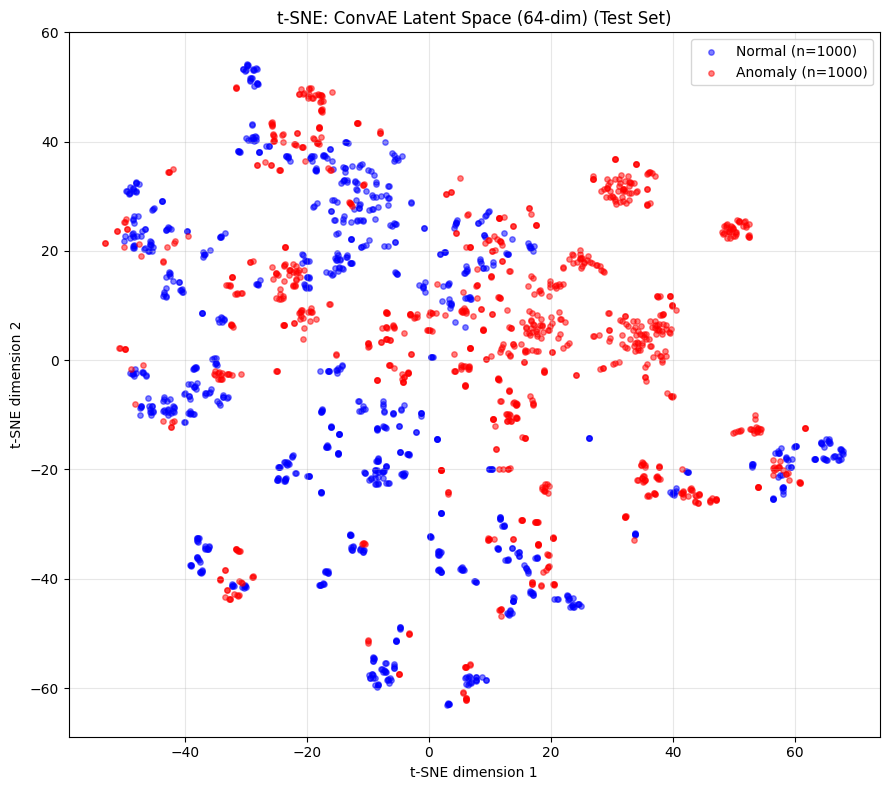

In [54]:
# t-SNE Visualization: ConvAE Latent Space and optional PANNs Embeddings
from sklearn.manifold import TSNE

max_samples = 2000

def subsample_and_combine(emb_normal, emb_anomaly, max_total=2000):
    if len(emb_normal) + len(emb_anomaly) > max_total:
        n_n = min(len(emb_normal), max_total // 2)
        n_a = min(len(emb_anomaly), max_total // 2)
        idx_n = np.random.choice(len(emb_normal), n_n, replace=False)
        idx_a = np.random.choice(len(emb_anomaly), n_a, replace=False)
        sub_n, sub_a = emb_normal[idx_n], emb_anomaly[idx_a]
    else:
        sub_n, sub_a = emb_normal, emb_anomaly
    combined = np.vstack([sub_n, sub_a])
    labels = np.array([0] * len(sub_n) + [1] * len(sub_a))
    return combined, labels, len(sub_n), len(sub_a)

plot_items = []
convae_combined, convae_labels, n_conv_n, n_conv_a = subsample_and_combine(latent_test_normal, latent_test_anomaly, max_samples)
print("Running t-SNE on ConvAE latent space...")
tsne_convae = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED, verbose=1)
plot_items.append((tsne_convae.fit_transform(convae_combined), convae_labels, "ConvAE Latent Space (64-dim)", n_conv_n, n_conv_a))

if panns_available:
    panns_combined, panns_labels, n_panns_n, n_panns_a = subsample_and_combine(panns_test_normal, panns_test_anomaly, max_samples)
    print("\nRunning t-SNE on PANNs embeddings...")
    tsne_panns = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED, verbose=1)
    plot_items.append((tsne_panns.fit_transform(panns_combined), panns_labels, "PANNs Embeddings (2048-dim)", n_panns_n, n_panns_a))

fig, axes = plt.subplots(1, len(plot_items), figsize=(9 * len(plot_items), 8))
if len(plot_items) == 1:
    axes = [axes]
for ax, (data_2d, labels, title, n_n, n_a) in zip(axes, plot_items):
    ax.scatter(data_2d[labels == 0, 0], data_2d[labels == 0, 1], c='blue', alpha=0.5, s=15, label=f'Normal (n={n_n})')
    ax.scatter(data_2d[labels == 1, 0], data_2d[labels == 1, 1], c='red', alpha=0.5, s=15, label=f'Anomaly (n={n_a})')
    ax.set_xlabel('t-SNE dimension 1')
    ax.set_ylabel('t-SNE dimension 2')
    ax.set_title(f't-SNE: {title} (Test Set)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure(fig, "tsne_embedding_visualization")
plt.show()

## 15. Per-Machine-ID Diagnostic Evaluation

This final diagnostic section breaks final-test predictions down by machine ID. It reuses the already trained models, final-test scores, thresholds, and metadata; it does not change the main evaluation protocol or retune any threshold.


Saved artifact: outputs/notebook_runs/20260620_212421/metrics/per_machine_final_test_summary.json
Saved per-machine file predictions: outputs/notebook_runs/20260620_212421/tables/per_machine_file_predictions.csv
Saved per-machine summary CSV: outputs/notebook_runs/20260620_212421/tables/per_machine_final_test_summary.csv
Saved per-machine summary TXT: outputs/notebook_runs/20260620_212421/tables/per_machine_final_test_summary.txt

Per-machine final-test summary:


,method,machine_id,normal_count,anomaly_count,false_positives,false_positive_rate,false_negatives,false_negative_rate,anomaly_recall,normal_recall,balanced_accuracy
0,ConvAE + IF,00,55,108,24,0.436364,47,0.435185,0.564815,0.563636,0.564226
1,ConvAE + IF,02,49,73,16,0.326531,28,0.383562,0.616438,0.673469,0.644954
2,ConvAE + IF,04,49,70,22,0.448980,29,0.414286,0.585714,0.551020,0.568367
3,ConvAE + IF,06,47,69,29,0.617021,32,0.463768,0.536232,0.382979,0.459605
4,ConvAE + LOF,00,55,108,8,0.145455,32,0.296296,0.703704,0.854545,0.779125
5,ConvAE + LOF,02,49,73,5,0.102041,32,0.438356,0.561644,0.897959,0.729802
6,ConvAE + LOF,04,49,70,8,0.163265,13,0.185714,0.814286,0.836735,0.825510
7,ConvAE + LOF,06,47,69,24,0.510638,22,0.318841,0.681159,0.489362,0.585261
8,ConvAE Recon Error,00,55,108,41,0.745455,34,0.314815,0.685185,0.254545,0.469865
9,ConvAE Recon Error,02,49,73,19,0.387755,42,0.575342,0.424658,0.612245,0.518451



Focused per-machine diagnostic for ConvAE + LOF:


,method,machine_id,normal_count,anomaly_count,false_positives,false_positive_rate,false_negatives,false_negative_rate,anomaly_recall,normal_recall,balanced_accuracy
4,ConvAE + LOF,00,55,108,8,0.145455,32,0.296296,0.703704,0.854545,0.779125
5,ConvAE + LOF,02,49,73,5,0.102041,32,0.438356,0.561644,0.897959,0.729802
6,ConvAE + LOF,04,49,70,8,0.163265,13,0.185714,0.814286,0.836735,0.825510
7,ConvAE + LOF,06,47,69,24,0.510638,22,0.318841,0.681159,0.489362,0.585261


Saved figure: outputs/notebook_runs/20260620_212421/figures/per_machine_error_rates.png


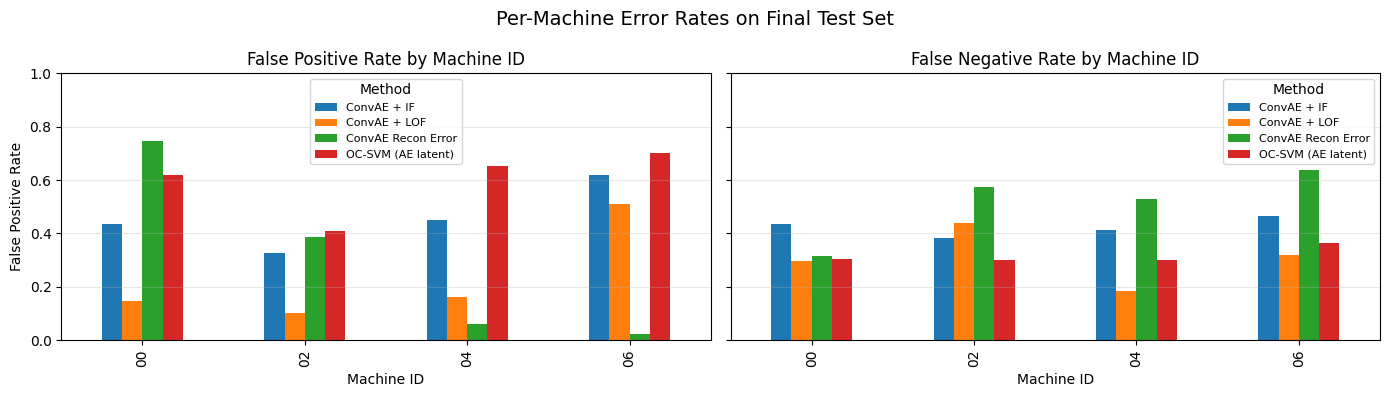

In [55]:
# Per-machine diagnostic evaluation on the final test set
import pandas as pd

MACHINE_ID_PATTERN = re.compile(r"^(?:normal|anomaly)_id_([^_]+)_")


def machine_id_from_metadata_item(item):
    """Extract machine ID from the dataset filename convention."""
    source_file = item.get("source_file") or Path(item.get("source_id", "")).name
    match = MACHINE_ID_PATTERN.match(source_file)
    if match is None:
        raise ValueError(f"Cannot parse machine ID from source_file={source_file!r}")
    return match.group(1)


def source_id_from_metadata_item(item):
    """Return the stable file identity used by aggregate_scores_to_files."""
    return item.get("source_id") or item["source_file"]


def file_machine_map(metadata):
    """Map file source_id to machine_id, verifying one machine ID per file."""
    mapping = {}
    for item in metadata:
        source_id = source_id_from_metadata_item(item)
        machine_id = machine_id_from_metadata_item(item)
        previous = mapping.setdefault(source_id, machine_id)
        if previous != machine_id:
            raise ValueError(f"Conflicting machine IDs for {source_id}: {previous} vs {machine_id}")
    return mapping


def aggregate_with_file_names(window_scores, metadata, strategy=AGGREGATION_STRATEGY):
    """Aggregate window scores and preserve file identities for diagnostics."""
    file_scores, file_names = aggregate_scores_to_files(window_scores, metadata, strategy=strategy)
    return np.asarray(file_scores), list(file_names)


def add_method_predictions(rows, method, normal_scores, normal_meta, anomaly_scores, anomaly_meta, threshold):
    """Append file-level predictions for one method to rows."""
    normal_file_scores, normal_files = aggregate_with_file_names(normal_scores, normal_meta)
    anomaly_file_scores, anomaly_files = aggregate_with_file_names(anomaly_scores, anomaly_meta)

    normal_machine_by_file = file_machine_map(normal_meta)
    anomaly_machine_by_file = file_machine_map(anomaly_meta)

    for source_id, score in zip(normal_files, normal_file_scores):
        pred_label = int(score >= threshold)
        rows.append({
            "method": method,
            "source_id": source_id,
            "machine_id": normal_machine_by_file[source_id],
            "true_label": 0,
            "score": float(score),
            "threshold": float(threshold),
            "pred_label": pred_label,
            "is_correct": bool(pred_label == 0),
        })

    for source_id, score in zip(anomaly_files, anomaly_file_scores):
        pred_label = int(score >= threshold)
        rows.append({
            "method": method,
            "source_id": source_id,
            "machine_id": anomaly_machine_by_file[source_id],
            "true_label": 1,
            "score": float(score),
            "threshold": float(threshold),
            "pred_label": pred_label,
            "is_correct": bool(pred_label == 1),
        })


per_machine_rows = []

# Assignment-aligned ConvAE methods.
add_method_predictions(
    per_machine_rows,
    "ConvAE Recon Error",
    recon_scores_test_normal,
    test_normal_meta,
    recon_scores_test_anomaly,
    test_anomaly_meta,
    thresh_recon,
)
add_method_predictions(
    per_machine_rows,
    "ConvAE + IF",
    if_scores_test_normal,
    test_normal_meta,
    if_scores_test_anomaly,
    test_anomaly_meta,
    thresh_if,
)
add_method_predictions(
    per_machine_rows,
    "ConvAE + LOF",
    lof_scores_test_normal,
    test_normal_meta,
    lof_scores_test_anomaly,
    test_anomaly_meta,
    thresh_lof,
)

# Classical latent-space and MFCC baselines. Scores are recomputed from already fitted models.
add_method_predictions(
    per_machine_rows,
    "OC-SVM (AE latent)",
    score_oc_svm(ocsvm_model, ocsvm_scaler, latent_test_normal),
    test_normal_meta,
    score_oc_svm(ocsvm_model, ocsvm_scaler, latent_test_anomaly),
    test_anomaly_meta,
    results_ocsvm["threshold"],
)
add_method_predictions(
    per_machine_rows,
    "SVM-sup (AE latent)",
    score_svm_supervised(svm_model, latent_test_normal),
    test_normal_meta,
    score_svm_supervised(svm_model, latent_test_anomaly),
    test_anomaly_meta,
    results_svm["threshold"],
)
add_method_predictions(
    per_machine_rows,
    "XGBoost (AE latent)",
    score_xgboost(xgb_model, latent_test_normal),
    test_normal_meta,
    score_xgboost(xgb_model, latent_test_anomaly),
    test_anomaly_meta,
    results_xgb["threshold"],
)
add_method_predictions(
    per_machine_rows,
    "SVM-sup (MFCC stats)",
    score_svm_supervised(mfcc_svm, M_test_normal),
    test_normal_meta,
    score_svm_supervised(mfcc_svm, M_test_anomaly),
    test_anomaly_meta,
    results_mfcc["threshold"],
)

# Optional PANNs methods, only when the optional baseline was computed.
if panns_available:
    add_method_predictions(
        per_machine_rows,
        "PANNs + LOF",
        panns_lof_test_normal,
        panns_test_normal_meta,
        panns_lof_test_anomaly,
        panns_test_anomaly_meta,
        thresh_panns_lof,
    )
    add_method_predictions(
        per_machine_rows,
        "PANNs + IF",
        panns_if_test_normal,
        panns_test_normal_meta,
        panns_if_test_anomaly,
        panns_test_anomaly_meta,
        thresh_panns_if,
    )

per_machine_predictions = pd.DataFrame(per_machine_rows)

expected_normal_counts = {"00": 55, "02": 49, "04": 49, "06": 47}
expected_anomaly_counts = {"00": 108, "02": 73, "04": 70, "06": 69}
observed_normal_counts = (
    per_machine_predictions[per_machine_predictions["true_label"] == 0]
    .drop_duplicates(["method", "source_id"])
    .groupby("machine_id")
    .size()
    .to_dict()
)
observed_anomaly_counts = (
    per_machine_predictions[per_machine_predictions["true_label"] == 1]
    .drop_duplicates(["method", "source_id"])
    .groupby("machine_id")
    .size()
    .to_dict()
)

# Counts are repeated once per method above; validate on one representative method.
representative_method = "ConvAE + LOF"
representative_rows = per_machine_predictions[per_machine_predictions["method"] == representative_method]
representative_normal_counts = (
    representative_rows[representative_rows["true_label"] == 0]
    .groupby("machine_id")
    .size()
    .to_dict()
)
representative_anomaly_counts = (
    representative_rows[representative_rows["true_label"] == 1]
    .groupby("machine_id")
    .size()
    .to_dict()
)
if representative_normal_counts != expected_normal_counts:
    raise AssertionError(f"Unexpected normal file counts: {representative_normal_counts}")
if representative_anomaly_counts != expected_anomaly_counts:
    raise AssertionError(f"Unexpected anomaly file counts: {representative_anomaly_counts}")

summary_rows = []
for (method, machine_id), group in per_machine_predictions.groupby(["method", "machine_id"], sort=True):
    normal = group[group["true_label"] == 0]
    anomaly = group[group["true_label"] == 1]

    normal_count = len(normal)
    anomaly_count = len(anomaly)
    false_positives = int(((normal["pred_label"] == 1)).sum())
    false_negatives = int(((anomaly["pred_label"] == 0)).sum())

    normal_recall = (normal_count - false_positives) / normal_count if normal_count else np.nan
    anomaly_recall = (anomaly_count - false_negatives) / anomaly_count if anomaly_count else np.nan

    summary_rows.append({
        "method": method,
        "machine_id": machine_id,
        "normal_count": int(normal_count),
        "anomaly_count": int(anomaly_count),
        "false_positives": false_positives,
        "false_positive_rate": false_positives / normal_count if normal_count else np.nan,
        "false_negatives": false_negatives,
        "false_negative_rate": false_negatives / anomaly_count if anomaly_count else np.nan,
        "anomaly_recall": anomaly_recall,
        "normal_recall": normal_recall,
        "balanced_accuracy": np.nanmean([normal_recall, anomaly_recall]),
    })

per_machine_summary = pd.DataFrame(summary_rows)

# Save detailed predictions and compact summaries.
if SAVE_OUTPUTS:
    predictions_path = TABLES_DIR / "per_machine_file_predictions.csv"
    summary_csv_path = TABLES_DIR / "per_machine_final_test_summary.csv"
    summary_txt_path = TABLES_DIR / "per_machine_final_test_summary.txt"
    summary_json_path = METRICS_DIR / "per_machine_final_test_summary.json"

    per_machine_predictions.to_csv(predictions_path, index=False)
    per_machine_summary.to_csv(summary_csv_path, index=False)
    summary_text = per_machine_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}")
    summary_txt_path.write_text(summary_text)
    save_json_artifact(per_machine_summary.to_dict(orient="records"), "per_machine_final_test_summary", subdir="metrics")

    print(f"Saved per-machine file predictions: {predictions_path}")
    print(f"Saved per-machine summary CSV: {summary_csv_path}")
    print(f"Saved per-machine summary TXT: {summary_txt_path}")

print("\nPer-machine final-test summary:")
display(per_machine_summary)

lof_focus = per_machine_summary[per_machine_summary["method"] == "ConvAE + LOF"].copy()
print("\nFocused per-machine diagnostic for ConvAE + LOF:")
display(lof_focus)

assignment_methods = ["ConvAE Recon Error", "ConvAE + IF", "ConvAE + LOF", "OC-SVM (AE latent)"]
plot_df = per_machine_summary[per_machine_summary["method"].isin(assignment_methods)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, metric, title in [
    (axes[0], "false_positive_rate", "False Positive Rate by Machine ID"),
    (axes[1], "false_negative_rate", "False Negative Rate by Machine ID"),
]:
    pivot = plot_df.pivot(index="machine_id", columns="method", values=metric).sort_index()
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Machine ID")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Method", fontsize=8)

plt.suptitle("Per-Machine Error Rates on Final Test Set", fontsize=14)
plt.tight_layout()
save_figure(fig, "per_machine_error_rates")
plt.show()


Saved figure: outputs/notebook_runs/20260620_212421/figures/per_machine_score_distributions.png


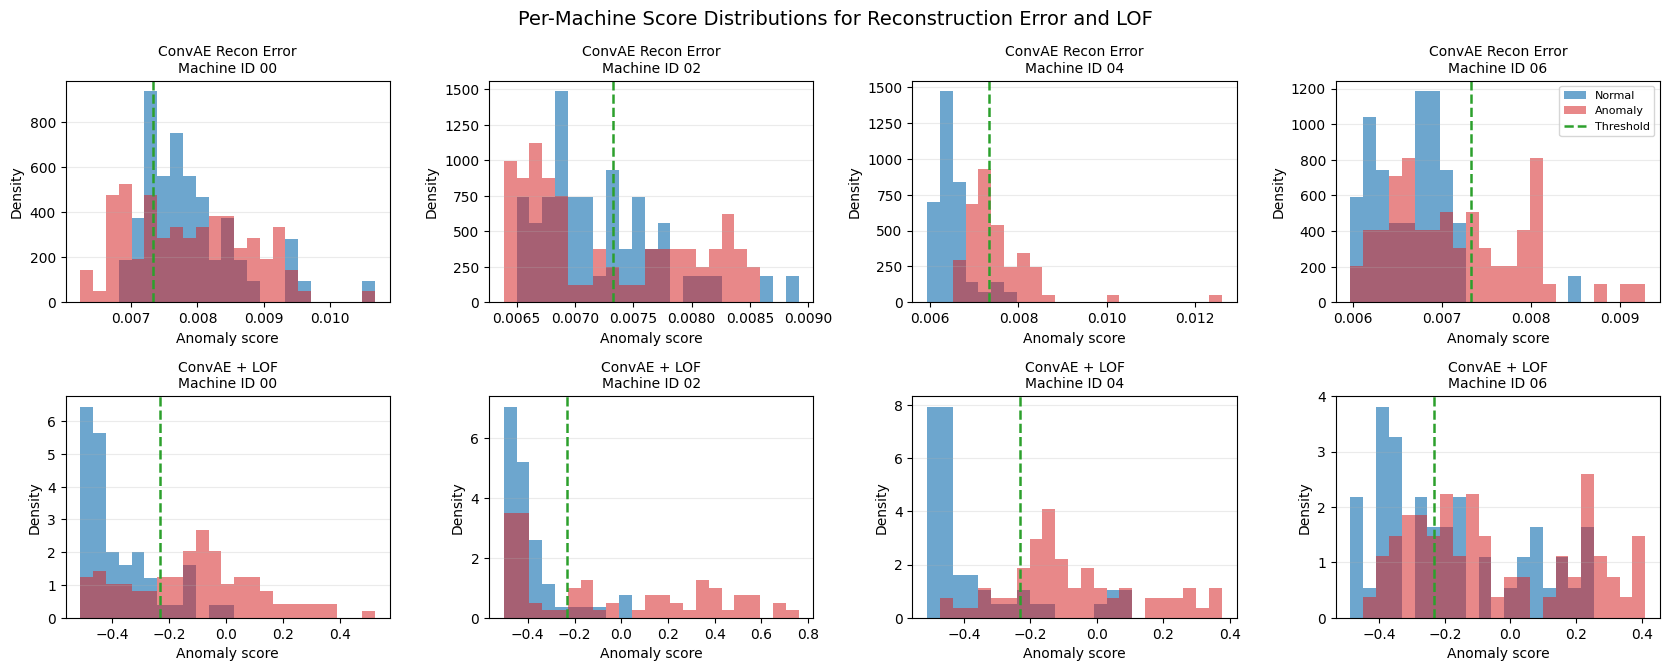

Saved artifact: outputs/notebook_runs/20260620_212421/metrics/per_machine_score_distribution_summary.json
Saved per-machine score distribution summary: outputs/notebook_runs/20260620_212421/tables/per_machine_score_distribution_summary.csv

Per-machine score distribution summary:


,method,machine_id,count,min,median,mean,max,label
0,ConvAE + LOF,00,55,-0.512865,-0.427767,-0.378255,0.005132,normal
1,ConvAE + LOF,00,108,-0.510047,-0.099385,-0.114562,0.525040,anomaly
2,ConvAE + LOF,02,49,-0.502847,-0.425700,-0.391069,0.031485,normal
3,ConvAE + LOF,02,73,-0.488638,-0.173401,-0.065132,0.759042,anomaly
4,ConvAE + LOF,04,49,-0.510413,-0.458937,-0.375199,0.102027,normal
5,ConvAE + LOF,04,70,-0.448157,-0.120342,-0.072825,0.375599,anomaly
6,ConvAE + LOF,06,47,-0.487715,-0.219380,-0.182425,0.251504,normal
7,ConvAE + LOF,06,69,-0.417780,-0.109505,-0.050215,0.410869,anomaly
8,ConvAE Recon Error,00,55,0.006868,0.007646,0.007897,0.010684,normal
9,ConvAE Recon Error,00,108,0.006232,0.007870,0.007893,0.010529,anomaly


In [57]:
# Per-machine score distributions for the two most informative ConvAE diagnostics
score_distribution_methods = ["ConvAE Recon Error", "ConvAE + LOF"]
score_distribution_df = per_machine_predictions[
    per_machine_predictions["method"].isin(score_distribution_methods)
].copy()

machine_ids = sorted(score_distribution_df["machine_id"].unique())
fig, axes = plt.subplots(
    len(score_distribution_methods),
    len(machine_ids),
    figsize=(4.2 * len(machine_ids), 3.4 * len(score_distribution_methods)),
    squeeze=False,
)

for row_idx, method in enumerate(score_distribution_methods):
    method_df = score_distribution_df[score_distribution_df["method"] == method]
    threshold = method_df["threshold"].iloc[0]

    for col_idx, machine_id in enumerate(machine_ids):
        ax = axes[row_idx, col_idx]
        subset = method_df[method_df["machine_id"] == machine_id]
        normal_scores = subset[subset["true_label"] == 0]["score"].to_numpy()
        anomaly_scores = subset[subset["true_label"] == 1]["score"].to_numpy()

        combined_scores = np.concatenate([normal_scores, anomaly_scores])
        if len(np.unique(combined_scores)) > 1:
            bins = np.linspace(combined_scores.min(), combined_scores.max(), 24)
        else:
            center = combined_scores[0]
            delta = max(abs(center) * 0.05, 1e-6)
            bins = np.linspace(center - delta, center + delta, 8)

        ax.hist(normal_scores, bins=bins, alpha=0.65, label="Normal", color="#1f77b4", density=True)
        ax.hist(anomaly_scores, bins=bins, alpha=0.55, label="Anomaly", color="#d62728", density=True)
        ax.axvline(threshold, color="#2ca02c", linestyle="--", linewidth=1.8, label="Threshold")
        ax.set_title(f"{method}\nMachine ID {machine_id}", fontsize=10)
        ax.set_xlabel("Anomaly score")
        ax.set_ylabel("Density")
        ax.grid(axis="y", alpha=0.25)

        if row_idx == 0 and col_idx == len(machine_ids) - 1:
            ax.legend(fontsize=8)

plt.suptitle("Per-Machine Score Distributions for Reconstruction Error and LOF", fontsize=14)
plt.tight_layout()
save_figure(fig, "per_machine_score_distributions")
plt.show()

score_distribution_summary = (
    score_distribution_df
    .groupby(["method", "machine_id", "true_label"])["score"]
    .agg(["count", "min", "median", "mean", "max"])
    .reset_index()
)
score_distribution_summary["label"] = score_distribution_summary["true_label"].map({0: "normal", 1: "anomaly"})
score_distribution_summary = score_distribution_summary.drop(columns=["true_label"])

if SAVE_OUTPUTS:
    score_distribution_summary_path = TABLES_DIR / "per_machine_score_distribution_summary.csv"
    score_distribution_summary.to_csv(score_distribution_summary_path, index=False)
    save_json_artifact(
        score_distribution_summary.to_dict(orient="records"),
        "per_machine_score_distribution_summary",
        subdir="metrics",
    )
    print(f"Saved per-machine score distribution summary: {score_distribution_summary_path}")

print("\nPer-machine score distribution summary:")
display(score_distribution_summary)


## 16. Protocol 2: ID06-Normal-Augmented ConvAE Training

This second protocol tests the diagnostic hypothesis that latent-space one-class detectors, especially LOF, treat normal ID `06` as out-of-distribution because ID `06` normal files are absent from the original ConvAE/LOF training set. The baseline protocol remains unchanged; this section uses separate variables, a separate checkpoint, and `protocol2_id06_aug_` artifact names.


In [58]:
# Protocol 2 split: add part of threshold-normal ID 06 to normal-only AE/detector training
PROTOCOL2_NAME = "protocol2_id06_aug"
PROTOCOL2_ID06_AUG_RATIO = 0.70
PROTOCOL2_AE_TRAIN_RATIO = 0.80
PROTOCOL2_SEED = SEED


def unique_source_ids_from_metadata(metadata):
    """Return source_ids in first-seen metadata order, one per file."""
    seen = set()
    source_ids = []
    for item in metadata:
        source_id = source_id_from_metadata_item(item)
        if source_id not in seen:
            seen.add(source_id)
            source_ids.append(source_id)
    return source_ids


def source_ids_for_machine(metadata, machine_id):
    """Return file source_ids for a machine ID in deterministic first-seen order."""
    return [
        source_id
        for source_id in unique_source_ids_from_metadata(metadata)
        if machine_id_from_metadata_item(next(item for item in metadata if source_id_from_metadata_item(item) == source_id)) == machine_id
    ]


def subset_windows_by_source_ids(specs, metadata, keep_source_ids):
    """Subset window-level specs/metadata by file-level source_id."""
    keep_source_ids = set(keep_source_ids)
    mask = np.array([source_id_from_metadata_item(item) in keep_source_ids for item in metadata], dtype=bool)
    subset_specs = specs[mask]
    subset_meta = [item for item, keep in zip(metadata, mask) if keep]
    return subset_specs, subset_meta


def exclude_windows_by_source_ids(specs, metadata, exclude_source_ids):
    """Remove window-level specs/metadata for selected file-level source_ids."""
    exclude_source_ids = set(exclude_source_ids)
    keep_source_ids = [
        source_id
        for source_id in unique_source_ids_from_metadata(metadata)
        if source_id not in exclude_source_ids
    ]
    return subset_windows_by_source_ids(specs, metadata, keep_source_ids)


id06_threshold_normal_ids_p2 = source_ids_for_machine(tune_normal_meta, "06")
rng_p2 = np.random.default_rng(PROTOCOL2_SEED)
shuffled_id06_ids_p2 = list(np.array(id06_threshold_normal_ids_p2)[rng_p2.permutation(len(id06_threshold_normal_ids_p2))])

n_id06_aug_files_p2 = int(len(shuffled_id06_ids_p2) * PROTOCOL2_ID06_AUG_RATIO)
id06_aug_ids_p2 = shuffled_id06_ids_p2[:n_id06_aug_files_p2]
id06_tune_keep_ids_p2 = shuffled_id06_ids_p2[n_id06_aug_files_p2:]

n_id06_aug_train_files_p2 = int(len(id06_aug_ids_p2) * PROTOCOL2_AE_TRAIN_RATIO)
id06_aug_train_ids_p2 = id06_aug_ids_p2[:n_id06_aug_train_files_p2]
id06_aug_val_ids_p2 = id06_aug_ids_p2[n_id06_aug_train_files_p2:]

id06_aug_train_specs_p2, id06_aug_train_meta_p2 = subset_windows_by_source_ids(
    tune_normal_specs, tune_normal_meta, id06_aug_train_ids_p2
)
id06_aug_val_specs_p2, id06_aug_val_meta_p2 = subset_windows_by_source_ids(
    tune_normal_specs, tune_normal_meta, id06_aug_val_ids_p2
)
tune_normal_specs_p2, tune_normal_meta_p2 = exclude_windows_by_source_ids(
    tune_normal_specs, tune_normal_meta, id06_aug_ids_p2
)

ae_train_specs_p2 = np.concatenate([ae_train_specs, id06_aug_train_specs_p2], axis=0)
ae_train_meta_p2 = ae_train_meta + id06_aug_train_meta_p2
ae_val_specs_p2 = np.concatenate([ae_val_specs, id06_aug_val_specs_p2], axis=0)
ae_val_meta_p2 = ae_val_meta + id06_aug_val_meta_p2

protocol2_split_summary = {
    "threshold_id06_files_total": len(id06_threshold_normal_ids_p2),
    "id06_aug_files_total": len(id06_aug_ids_p2),
    "id06_aug_train_files": len(id06_aug_train_ids_p2),
    "id06_aug_val_files": len(id06_aug_val_ids_p2),
    "id06_threshold_files_kept": len(id06_tune_keep_ids_p2),
    "threshold_normal_files_baseline": len(unique_source_ids_from_metadata(tune_normal_meta)),
    "threshold_normal_files_protocol2": len(unique_source_ids_from_metadata(tune_normal_meta_p2)),
    "final_test_normal_files": len(unique_source_ids_from_metadata(test_normal_meta)),
    "final_test_anomaly_files": len(unique_source_ids_from_metadata(test_anomaly_meta)),
}

expected_tune_normal_files_p2 = protocol2_split_summary["threshold_normal_files_baseline"] - len(id06_aug_ids_p2)
assert protocol2_split_summary["threshold_normal_files_protocol2"] == expected_tune_normal_files_p2
assert protocol2_split_summary["final_test_normal_files"] == 200
assert protocol2_split_summary["final_test_anomaly_files"] == 320
assert len(id06_aug_train_ids_p2) > 0 and len(id06_aug_val_ids_p2) > 0
assert all(machine_id_from_metadata_item(item) == "06" for item in id06_aug_train_meta_p2 + id06_aug_val_meta_p2)

print("Protocol 2 split summary:")
for key, value in protocol2_split_summary.items():
    print(f"  {key}: {value}")

save_json_artifact(protocol2_split_summary, "protocol2_id06_aug_split_summary", subdir="metrics")


Protocol 2 split summary:
  threshold_id06_files_total: 53
  id06_aug_files_total: 37
  id06_aug_train_files: 29
  id06_aug_val_files: 8
  id06_threshold_files_kept: 16
  threshold_normal_files_baseline: 200
  threshold_normal_files_protocol2: 163
  final_test_normal_files: 200
  final_test_anomaly_files: 320
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/protocol2_id06_aug_split_summary.json


PosixPath('outputs/notebook_runs/20260620_212421/metrics/protocol2_id06_aug_split_summary.json')

Initialized new Protocol 2 ConvAE model.
Protocol 2 AE train windows: 16389
Protocol 2 AE val windows:   4113
Protocol 2 model on device: mps
Training Protocol 2 ConvAE for up to 100 epochs
------------------------------------------------------------
Epoch   1/100 | Train: 0.013567 | Val: 0.011519 | LR: 1.00e-03 | Time: 71.6s
Epoch   2/100 | Train: 0.008569 | Val: 0.008900 | LR: 1.00e-03 | Time: 138.8s
Epoch   3/100 | Train: 0.008145 | Val: 0.008523 | LR: 1.00e-03 | Time: 144.6s
Epoch   4/100 | Train: 0.007974 | Val: 0.008171 | LR: 1.00e-03 | Time: 54.0s
Epoch   5/100 | Train: 0.007859 | Val: 0.008056 | LR: 1.00e-03 | Time: 43.2s
Epoch   6/100 | Train: 0.007791 | Val: 0.010263 | LR: 1.00e-03 | Time: 41.9s
Epoch   7/100 | Train: 0.007769 | Val: 0.008106 | LR: 1.00e-03 | Time: 39.8s
Epoch   8/100 | Train: 0.007707 | Val: 0.007912 | LR: 1.00e-03 | Time: 41.7s
Epoch   9/100 | Train: 0.007694 | Val: 0.007794 | LR: 1.00e-03 | Time: 41.7s
Epoch  10/100 | Train: 0.007683 | Val: 0.008399 | LR: 

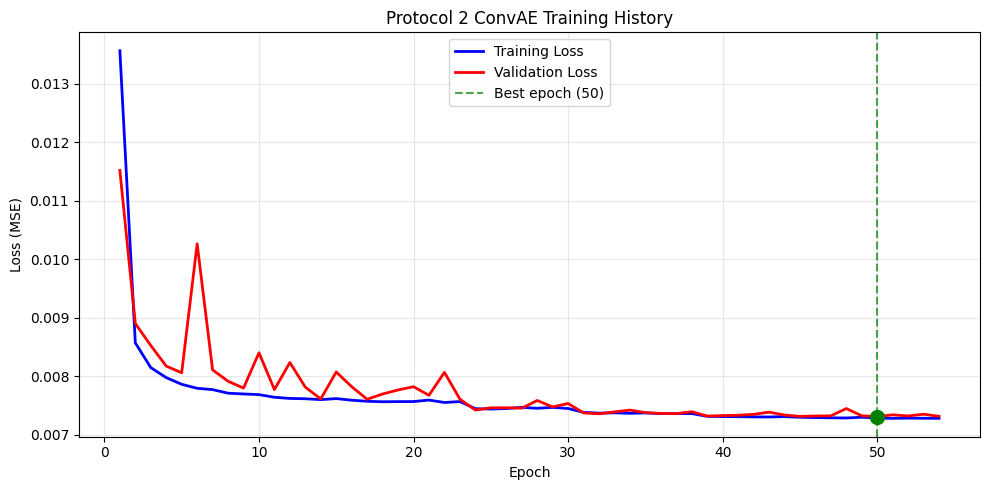

In [59]:
# Protocol 2 ConvAE: train or load a separate ID06-augmented checkpoint
checkpoint_path_p2 = Path("checkpoints") / "conv_ae_protocol2_id06_aug.pt"
FORCE_RETRAIN_PROTOCOL2_AE = False

train_dataset_p2 = SpectrogramDataset(ae_train_specs_p2)
val_dataset_p2 = SpectrogramDataset(ae_val_specs_p2)
train_generator_p2 = torch.Generator().manual_seed(PROTOCOL2_SEED)
train_loader_p2 = DataLoader(
    train_dataset_p2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=train_generator_p2,
)
val_loader_p2 = DataLoader(val_dataset_p2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

if checkpoint_path_p2.exists() and not FORCE_RETRAIN_PROTOCOL2_AE:
    model_p2, ae_config_p2, history_p2 = load_checkpoint(checkpoint_path_p2, device)
    model_loaded_from_checkpoint_p2 = True
    optimizer_p2 = None
    scheduler_p2 = None
    print(f"Loaded existing Protocol 2 ConvAE checkpoint: {checkpoint_path_p2}")
else:
    torch.manual_seed(PROTOCOL2_SEED + 206)
    ae_config_p2 = ae_config
    model_p2 = ConvAE(ae_config_p2).to(device)
    history_p2 = {"train_loss": [], "val_loss": [], "lr": []}
    model_loaded_from_checkpoint_p2 = False
    print("Initialized new Protocol 2 ConvAE model.")

print(f"Protocol 2 AE train windows: {len(ae_train_specs_p2)}")
print(f"Protocol 2 AE val windows:   {len(ae_val_specs_p2)}")
print(f"Protocol 2 model on device: {device}")

if model_loaded_from_checkpoint_p2:
    print("Skipping Protocol 2 ConvAE training because an existing checkpoint was loaded.")
else:
    criterion_p2 = torch.nn.MSELoss()
    optimizer_p2 = torch.optim.Adam(
        model_p2.parameters(),
        lr=ae_config_p2.learning_rate,
        weight_decay=ae_config_p2.weight_decay,
    )

    scheduler_p2 = None
    if ae_config_p2.use_scheduler:
        scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_p2,
            mode="min",
            factor=ae_config_p2.scheduler_factor,
            patience=ae_config_p2.scheduler_patience,
        )

    best_val_loss_p2 = float("inf")
    best_model_state_p2 = None
    patience_counter_p2 = 0

    print(f"Training Protocol 2 ConvAE for up to {ae_config_p2.epochs} epochs")
    print("-" * 60)

    for epoch in range(ae_config_p2.epochs):
        start_time = time.time()
        train_loss = train_epoch(model_p2, train_loader_p2, optimizer_p2, criterion_p2, device)
        val_loss = validate(model_p2, val_loader_p2, criterion_p2, device)
        epoch_time = time.time() - start_time

        current_lr = optimizer_p2.param_groups[0]["lr"]
        history_p2["train_loss"].append(train_loss)
        history_p2["val_loss"].append(val_loss)
        history_p2["lr"].append(current_lr)

        if val_loss < best_val_loss_p2 - ae_config_p2.min_delta:
            best_val_loss_p2 = val_loss
            best_model_state_p2 = {k: v.cpu().clone() for k, v in model_p2.state_dict().items()}
            patience_counter_p2 = 0
        else:
            patience_counter_p2 += 1

        print(f"Epoch {epoch+1:3d}/{ae_config_p2.epochs} | "
              f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
              f"LR: {current_lr:.2e} | Time: {epoch_time:.1f}s")

        if scheduler_p2 is not None:
            scheduler_p2.step(val_loss)

        if patience_counter_p2 >= ae_config_p2.patience:
            print(f"\nProtocol 2 early stopping at epoch {epoch+1}")
            break

    if best_model_state_p2 is not None:
        model_p2.load_state_dict(best_model_state_p2)
        print(f"\nRestored Protocol 2 best model with val_loss: {best_val_loss_p2:.6f}")

    save_checkpoint(model_p2, optimizer_p2, ae_config_p2, history_p2, checkpoint_path_p2, scheduler_p2)
    print(f"Saved Protocol 2 checkpoint: {checkpoint_path_p2}")

if history_p2.get("train_loss") and history_p2.get("val_loss"):
    fig, ax = plot_training_history(history_p2)
    ax.set_title("Protocol 2 ConvAE Training History")
    save_figure(fig, "protocol2_id06_aug_training_history")
    save_json_artifact(history_p2, "protocol2_id06_aug_training_history", subdir="metrics")
    plt.show()
else:
    print("No Protocol 2 training history available.")


In [60]:
# Protocol 2 evaluation: reconstruction error, IF, LOF, and OC-SVM on the ID06-augmented ConvAE latent space
all_train_specs_p2 = np.concatenate([ae_train_specs_p2, ae_val_specs_p2], axis=0)
all_train_meta_p2 = ae_train_meta_p2 + ae_val_meta_p2
train_all_dataset_p2 = SpectrogramDataset(all_train_specs_p2)
train_all_loader_p2 = DataLoader(train_all_dataset_p2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

tune_normal_dataset_p2 = SpectrogramDataset(tune_normal_specs_p2)
tune_normal_loader_p2 = DataLoader(tune_normal_dataset_p2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Extracting Protocol 2 latent representations...")
latent_train_p2 = extract_latent_representations(model_p2, train_all_loader_p2, device)
latent_tune_normal_p2 = extract_latent_representations(model_p2, tune_normal_loader_p2, device)
latent_tune_anomaly_p2 = extract_latent_representations(model_p2, tune_anomaly_loader, device)
latent_test_normal_p2 = extract_latent_representations(model_p2, test_normal_loader, device)
latent_test_anomaly_p2 = extract_latent_representations(model_p2, test_anomaly_loader, device)

print("Training Protocol 2 Isolation Forest and LOF...")
iforest_p2 = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=PROTOCOL2_SEED,
    n_jobs=-1,
)
iforest_p2.fit(latent_train_p2)

lof_p2 = LocalOutlierFactor(
    n_neighbors=30,
    contamination="auto",
    novelty=True,
    n_jobs=-1,
)
lof_p2.fit(latent_train_p2)

print("Computing Protocol 2 window-level scores...")
recon_scores_tune_normal_p2 = extract_reconstruction_errors(model_p2, tune_normal_loader_p2, device)
recon_scores_tune_anomaly_p2 = extract_reconstruction_errors(model_p2, tune_anomaly_loader, device)
recon_scores_test_normal_p2 = extract_reconstruction_errors(model_p2, test_normal_loader, device)
recon_scores_test_anomaly_p2 = extract_reconstruction_errors(model_p2, test_anomaly_loader, device)

if_scores_tune_normal_p2 = -iforest_p2.decision_function(latent_tune_normal_p2)
if_scores_tune_anomaly_p2 = -iforest_p2.decision_function(latent_tune_anomaly_p2)
if_scores_test_normal_p2 = -iforest_p2.decision_function(latent_test_normal_p2)
if_scores_test_anomaly_p2 = -iforest_p2.decision_function(latent_test_anomaly_p2)

lof_scores_tune_normal_p2 = -lof_p2.decision_function(latent_tune_normal_p2)
lof_scores_tune_anomaly_p2 = -lof_p2.decision_function(latent_tune_anomaly_p2)
lof_scores_test_normal_p2 = -lof_p2.decision_function(latent_test_normal_p2)
lof_scores_test_anomaly_p2 = -lof_p2.decision_function(latent_test_anomaly_p2)


def evaluate_protocol2_window_scores(name, tune_scores_normal, tune_scores_anomaly, test_scores_normal, test_scores_anomaly):
    """Tune a Protocol 2 file-level threshold and evaluate on the unchanged final test set."""
    tune_file_normal, _ = aggregate_scores_to_files(tune_scores_normal, tune_normal_meta_p2, strategy=AGGREGATION_STRATEGY)
    tune_file_anomaly, _ = aggregate_scores_to_files(tune_scores_anomaly, tune_anomaly_meta, strategy=AGGREGATION_STRATEGY)
    threshold, tune_metrics = find_optimal_threshold(tune_file_normal, tune_file_anomaly, metric=THRESHOLD_METRIC)

    test_file_normal, _ = aggregate_scores_to_files(test_scores_normal, test_normal_meta, strategy=AGGREGATION_STRATEGY)
    test_file_anomaly, _ = aggregate_scores_to_files(test_scores_anomaly, test_anomaly_meta, strategy=AGGREGATION_STRATEGY)
    results = evaluate_detection(test_file_normal, test_file_anomaly, threshold)
    return attach_protocol(results, name, THRESHOLD_METRIC, AGGREGATION_STRATEGY, tune_metrics)

results_recon_p2 = evaluate_protocol2_window_scores(
    "Protocol 2 ConvAE Recon Error",
    recon_scores_tune_normal_p2,
    recon_scores_tune_anomaly_p2,
    recon_scores_test_normal_p2,
    recon_scores_test_anomaly_p2,
)
results_if_p2 = evaluate_protocol2_window_scores(
    "Protocol 2 ConvAE + IF",
    if_scores_tune_normal_p2,
    if_scores_tune_anomaly_p2,
    if_scores_test_normal_p2,
    if_scores_test_anomaly_p2,
)
results_lof_p2 = evaluate_protocol2_window_scores(
    "Protocol 2 ConvAE + LOF",
    lof_scores_tune_normal_p2,
    lof_scores_tune_anomaly_p2,
    lof_scores_test_normal_p2,
    lof_scores_test_anomaly_p2,
)

print("Tuning Protocol 2 OC-SVM nu on the reduced threshold split...")
best_ocsvm_p2 = {"nu": None, "balanced_accuracy": -1, "model": None, "scaler": None}
for nu in [0.05, 0.1, 0.2]:
    candidate_model_p2, candidate_scaler_p2 = fit_oc_svm(latent_train_p2, nu=nu, gamma="scale")
    tune_n_p2 = score_oc_svm(candidate_model_p2, candidate_scaler_p2, latent_tune_normal_p2)
    tune_a_p2 = score_oc_svm(candidate_model_p2, candidate_scaler_p2, latent_tune_anomaly_p2)
    file_n_p2, _ = aggregate_scores_to_files(tune_n_p2, tune_normal_meta_p2, strategy=AGGREGATION_STRATEGY)
    file_a_p2, _ = aggregate_scores_to_files(tune_a_p2, tune_anomaly_meta, strategy=AGGREGATION_STRATEGY)
    _, tune_metrics_p2 = find_optimal_threshold(file_n_p2, file_a_p2, metric=THRESHOLD_METRIC)
    print(f"Protocol 2 OC-SVM nu={nu}: tune BA={tune_metrics_p2['balanced_accuracy']:.4f}")
    if tune_metrics_p2["balanced_accuracy"] > best_ocsvm_p2["balanced_accuracy"]:
        best_ocsvm_p2.update({
            "nu": nu,
            "balanced_accuracy": tune_metrics_p2["balanced_accuracy"],
            "model": candidate_model_p2,
            "scaler": candidate_scaler_p2,
        })

ocsvm_model_p2 = best_ocsvm_p2["model"]
ocsvm_scaler_p2 = best_ocsvm_p2["scaler"]
results_ocsvm_p2 = evaluate_protocol2_window_scores(
    "Protocol 2 OC-SVM (AE latent)",
    score_oc_svm(ocsvm_model_p2, ocsvm_scaler_p2, latent_tune_normal_p2),
    score_oc_svm(ocsvm_model_p2, ocsvm_scaler_p2, latent_tune_anomaly_p2),
    score_oc_svm(ocsvm_model_p2, ocsvm_scaler_p2, latent_test_normal_p2),
    score_oc_svm(ocsvm_model_p2, ocsvm_scaler_p2, latent_test_anomaly_p2),
)
results_ocsvm_p2["best_nu"] = best_ocsvm_p2["nu"]

protocol2_results_dict = {
    "Protocol 2 ConvAE Recon Error": results_recon_p2,
    "Protocol 2 ConvAE + IF": results_if_p2,
    "Protocol 2 ConvAE + LOF": results_lof_p2,
    "Protocol 2 OC-SVM (AE latent)": results_ocsvm_p2,
}

print("\n" + "=" * 100)
print(" PROTOCOL 2 ID06-AUGMENTED FINAL TEST RESULTS ".center(100, "="))
print("=" * 100 + "\n")
protocol2_table = save_comparison_table(protocol2_results_dict, "protocol2_id06_aug_final_test_results")
print(protocol2_table)

baseline_vs_protocol2_results_dict = {
    "Baseline ConvAE Recon Error": results_recon,
    "Protocol 2 ConvAE Recon Error": results_recon_p2,
    "Baseline ConvAE + IF": results_if,
    "Protocol 2 ConvAE + IF": results_if_p2,
    "Baseline ConvAE + LOF": results_lof,
    "Protocol 2 ConvAE + LOF": results_lof_p2,
    "Baseline OC-SVM (AE latent)": results_ocsvm,
    "Protocol 2 OC-SVM (AE latent)": results_ocsvm_p2,
}
baseline_vs_protocol2_table = save_comparison_table(
    baseline_vs_protocol2_results_dict,
    "protocol2_id06_aug_baseline_comparison",
)
print("\nBaseline vs Protocol 2 comparison:")
print(baseline_vs_protocol2_table)


Extracting Protocol 2 latent representations...
Training Protocol 2 Isolation Forest and LOF...
Computing Protocol 2 window-level scores...
Tuning Protocol 2 OC-SVM nu on the reduced threshold split...
Protocol 2 OC-SVM nu=0.05: tune BA=0.6320
Protocol 2 OC-SVM nu=0.1: tune BA=0.6320
Protocol 2 OC-SVM nu=0.2: tune BA=0.6326

=========================== PROTOCOL 2 ID06-AUGMENTED FINAL TEST RESULTS ===========================

Saved artifact: outputs/notebook_runs/20260620_212421/tables/protocol2_id06_aug_final_test_results.txt
Saved artifact: outputs/notebook_runs/20260620_212421/tables/protocol2_id06_aug_final_test_results.csv
Saved artifact: outputs/notebook_runs/20260620_212421/metrics/protocol2_id06_aug_final_test_results.json
Method                      Accuracy    Bal Acc  Precision     Recall         F1    AUC-ROC     AUC-PR
------------------------------------------------------------------------------------------------------
Protocol 2 ConvAE Recon Error     0.6712     0.5894   

Saved artifact: outputs/notebook_runs/20260620_212421/metrics/protocol2_id06_aug_per_machine_summary.json
Saved Protocol 2 per-machine predictions: outputs/notebook_runs/20260620_212421/tables/protocol2_id06_aug_per_machine_file_predictions.csv
Saved Protocol 2 per-machine summary CSV: outputs/notebook_runs/20260620_212421/tables/protocol2_id06_aug_per_machine_summary.csv
Saved Protocol 2 per-machine summary TXT: outputs/notebook_runs/20260620_212421/tables/protocol2_id06_aug_per_machine_summary.txt

Protocol 2 per-machine summary:


,method,machine_id,normal_count,anomaly_count,false_positives,false_positive_rate,false_negatives,false_negative_rate,anomaly_recall,normal_recall,balanced_accuracy
0,Protocol 2 ConvAE + IF,00,55,108,31,0.563636,35,0.324074,0.675926,0.436364,0.556145
1,Protocol 2 ConvAE + IF,02,49,73,22,0.448980,25,0.342466,0.657534,0.551020,0.604277
2,Protocol 2 ConvAE + IF,04,49,70,32,0.653061,24,0.342857,0.657143,0.346939,0.502041
3,Protocol 2 ConvAE + IF,06,47,69,30,0.638298,29,0.420290,0.579710,0.361702,0.470706
4,Protocol 2 ConvAE + LOF,00,55,108,9,0.163636,33,0.305556,0.694444,0.836364,0.765404
5,Protocol 2 ConvAE + LOF,02,49,73,5,0.102041,32,0.438356,0.561644,0.897959,0.729802
6,Protocol 2 ConvAE + LOF,04,49,70,9,0.183673,12,0.171429,0.828571,0.816327,0.822449
7,Protocol 2 ConvAE + LOF,06,47,69,19,0.404255,24,0.347826,0.652174,0.595745,0.623959
8,Protocol 2 ConvAE Recon Error,00,55,108,55,1.000000,3,0.027778,0.972222,0.000000,0.486111
9,Protocol 2 ConvAE Recon Error,02,49,73,49,1.000000,4,0.054795,0.945205,0.000000,0.472603


Saved figure: outputs/notebook_runs/20260620_212421/figures/protocol2_id06_aug_per_machine_error_rates.png


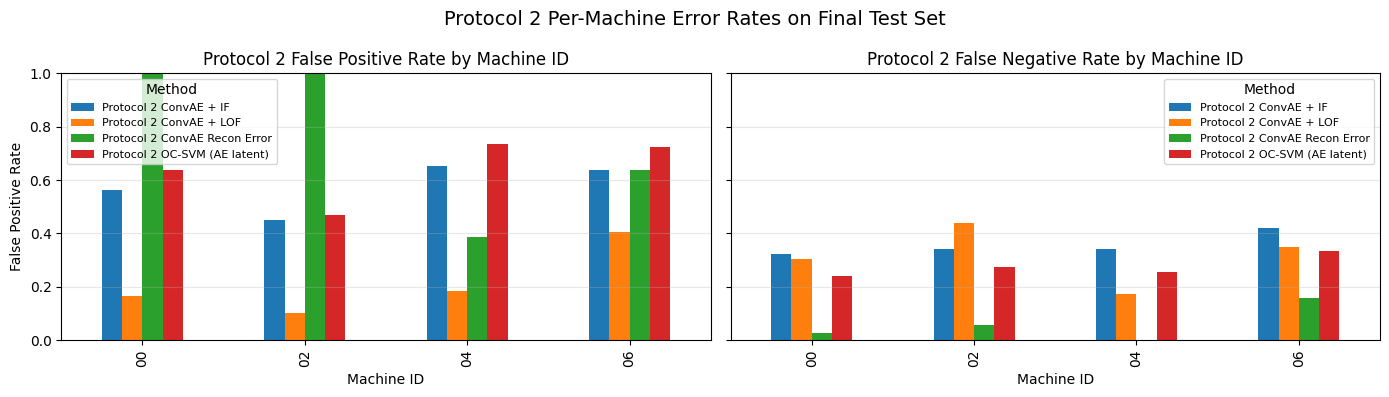

Saved artifact: outputs/notebook_runs/20260620_212421/metrics/protocol2_id06_aug_focused_lof_comparison.json
Saved focused Protocol 2 LOF comparison: outputs/notebook_runs/20260620_212421/tables/protocol2_id06_aug_focused_lof_comparison.csv

Focused baseline vs Protocol 2 comparison for ConvAE + LOF:


,protocol,method,balanced_accuracy,auc_roc,id06_false_positive_rate,id06_false_negative_rate,id06_balanced_accuracy
0,Baseline,ConvAE + LOF,0.732813,0.788047,0.510638,0.318841,0.585261
1,Protocol 2 ID06 Aug,ConvAE + LOF,0.737187,0.809719,0.404255,0.347826,0.623959


In [61]:
# Protocol 2 per-machine diagnostics and focused baseline-vs-protocol comparison
per_machine_rows_p2 = []
add_method_predictions(
    per_machine_rows_p2,
    "Protocol 2 ConvAE Recon Error",
    recon_scores_test_normal_p2,
    test_normal_meta,
    recon_scores_test_anomaly_p2,
    test_anomaly_meta,
    results_recon_p2["threshold"],
)
add_method_predictions(
    per_machine_rows_p2,
    "Protocol 2 ConvAE + IF",
    if_scores_test_normal_p2,
    test_normal_meta,
    if_scores_test_anomaly_p2,
    test_anomaly_meta,
    results_if_p2["threshold"],
)
add_method_predictions(
    per_machine_rows_p2,
    "Protocol 2 ConvAE + LOF",
    lof_scores_test_normal_p2,
    test_normal_meta,
    lof_scores_test_anomaly_p2,
    test_anomaly_meta,
    results_lof_p2["threshold"],
)
add_method_predictions(
    per_machine_rows_p2,
    "Protocol 2 OC-SVM (AE latent)",
    score_oc_svm(ocsvm_model_p2, ocsvm_scaler_p2, latent_test_normal_p2),
    test_normal_meta,
    score_oc_svm(ocsvm_model_p2, ocsvm_scaler_p2, latent_test_anomaly_p2),
    test_anomaly_meta,
    results_ocsvm_p2["threshold"],
)

per_machine_predictions_p2 = pd.DataFrame(per_machine_rows_p2)
summary_rows_p2 = []
for (method, machine_id), group in per_machine_predictions_p2.groupby(["method", "machine_id"], sort=True):
    normal = group[group["true_label"] == 0]
    anomaly = group[group["true_label"] == 1]

    normal_count = len(normal)
    anomaly_count = len(anomaly)
    false_positives = int((normal["pred_label"] == 1).sum())
    false_negatives = int((anomaly["pred_label"] == 0).sum())
    normal_recall = (normal_count - false_positives) / normal_count if normal_count else np.nan
    anomaly_recall = (anomaly_count - false_negatives) / anomaly_count if anomaly_count else np.nan

    summary_rows_p2.append({
        "method": method,
        "machine_id": machine_id,
        "normal_count": int(normal_count),
        "anomaly_count": int(anomaly_count),
        "false_positives": false_positives,
        "false_positive_rate": false_positives / normal_count if normal_count else np.nan,
        "false_negatives": false_negatives,
        "false_negative_rate": false_negatives / anomaly_count if anomaly_count else np.nan,
        "anomaly_recall": anomaly_recall,
        "normal_recall": normal_recall,
        "balanced_accuracy": np.nanmean([normal_recall, anomaly_recall]),
    })

per_machine_summary_p2 = pd.DataFrame(summary_rows_p2)

representative_rows_p2 = per_machine_predictions_p2[per_machine_predictions_p2["method"] == "Protocol 2 ConvAE + LOF"]
representative_normal_counts_p2 = (
    representative_rows_p2[representative_rows_p2["true_label"] == 0]
    .groupby("machine_id")
    .size()
    .to_dict()
)
representative_anomaly_counts_p2 = (
    representative_rows_p2[representative_rows_p2["true_label"] == 1]
    .groupby("machine_id")
    .size()
    .to_dict()
)
assert representative_normal_counts_p2 == expected_normal_counts
assert representative_anomaly_counts_p2 == expected_anomaly_counts

if SAVE_OUTPUTS:
    predictions_path_p2 = TABLES_DIR / "protocol2_id06_aug_per_machine_file_predictions.csv"
    summary_csv_path_p2 = TABLES_DIR / "protocol2_id06_aug_per_machine_summary.csv"
    summary_txt_path_p2 = TABLES_DIR / "protocol2_id06_aug_per_machine_summary.txt"
    per_machine_predictions_p2.to_csv(predictions_path_p2, index=False)
    per_machine_summary_p2.to_csv(summary_csv_path_p2, index=False)
    summary_text_p2 = per_machine_summary_p2.to_string(index=False, float_format=lambda x: f"{x:.4f}")
    summary_txt_path_p2.write_text(summary_text_p2)
    save_json_artifact(per_machine_summary_p2.to_dict(orient="records"), "protocol2_id06_aug_per_machine_summary", subdir="metrics")
    print(f"Saved Protocol 2 per-machine predictions: {predictions_path_p2}")
    print(f"Saved Protocol 2 per-machine summary CSV: {summary_csv_path_p2}")
    print(f"Saved Protocol 2 per-machine summary TXT: {summary_txt_path_p2}")

print("\nProtocol 2 per-machine summary:")
display(per_machine_summary_p2)

plot_df_p2 = per_machine_summary_p2.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, metric, title in [
    (axes[0], "false_positive_rate", "Protocol 2 False Positive Rate by Machine ID"),
    (axes[1], "false_negative_rate", "Protocol 2 False Negative Rate by Machine ID"),
]:
    pivot = plot_df_p2.pivot(index="machine_id", columns="method", values=metric).sort_index()
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Machine ID")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Method", fontsize=8)

plt.suptitle("Protocol 2 Per-Machine Error Rates on Final Test Set", fontsize=14)
plt.tight_layout()
save_figure(fig, "protocol2_id06_aug_per_machine_error_rates")
plt.show()


def method_machine_row(summary_df, method, machine_id="06"):
    machine_key = summary_df["machine_id"].astype(str).str.zfill(2)
    row = summary_df[(summary_df["method"] == method) & (machine_key == machine_id)]
    if len(row) != 1:
        raise ValueError(f"Expected one row for {method} machine {machine_id}, got {len(row)}")
    return row.iloc[0]

baseline_lof_id06 = method_machine_row(per_machine_summary, "ConvAE + LOF", "06")
protocol2_lof_id06 = method_machine_row(per_machine_summary_p2, "Protocol 2 ConvAE + LOF", "06")

focused_protocol2_comparison = pd.DataFrame([
    {
        "protocol": "Baseline",
        "method": "ConvAE + LOF",
        "balanced_accuracy": results_lof["balanced_accuracy"],
        "auc_roc": results_lof["auc_roc"],
        "id06_false_positive_rate": baseline_lof_id06["false_positive_rate"],
        "id06_false_negative_rate": baseline_lof_id06["false_negative_rate"],
        "id06_balanced_accuracy": baseline_lof_id06["balanced_accuracy"],
    },
    {
        "protocol": "Protocol 2 ID06 Aug",
        "method": "ConvAE + LOF",
        "balanced_accuracy": results_lof_p2["balanced_accuracy"],
        "auc_roc": results_lof_p2["auc_roc"],
        "id06_false_positive_rate": protocol2_lof_id06["false_positive_rate"],
        "id06_false_negative_rate": protocol2_lof_id06["false_negative_rate"],
        "id06_balanced_accuracy": protocol2_lof_id06["balanced_accuracy"],
    },
])

if SAVE_OUTPUTS:
    focused_path = TABLES_DIR / "protocol2_id06_aug_focused_lof_comparison.csv"
    focused_protocol2_comparison.to_csv(focused_path, index=False)
    save_json_artifact(
        focused_protocol2_comparison.to_dict(orient="records"),
        "protocol2_id06_aug_focused_lof_comparison",
        subdir="metrics",
    )
    print(f"Saved focused Protocol 2 LOF comparison: {focused_path}")

print("\nFocused baseline vs Protocol 2 comparison for ConvAE + LOF:")
display(focused_protocol2_comparison)
